In [ ]:
"""
Boring Bar — GA-Driven Multi-Objective Optimization  (PHYSICS-CORRECTED)
==========================================================================
Same architecture as the previous GA version (NSGA-II outer + inner GA
for kd/cd tuning), but with the rotordynamic terms in build_MK / frf
corrected to match the paper's Eq. (3) kinetic energy term-by-term.

────────────────────────────────────────────────────────────────────────
WHAT WAS WRONG AND WHAT CHANGED  (see chat explanation before this file)
────────────────────────────────────────────────────────────────────────
Paper Eq. (3), per unit length, beam kinetic energy:

  T = (1/2)∫ [ ρA(u̇²+v̇²)                      ← translational mass
             + 2Ω·ρA(v·u̇ − u·v̇)               ← TRANSLATIONAL CORIOLIS
             + Ω²·ρA(u²+v²)                    ← CENTRIFUGAL (ρA only)
             + ρIp·Ω²                          ← const, drops out of EOM
             + ρI(θ̇x²+θ̇y²)                     ← rotary inertia
             + 2ρIp·Ω(θy'·θ̇x' − θx'·θ̇y')      ← GYROSCOPIC (ρIp only)
           ] dz

Previous code:
  • Gyroscopic (Gg, built from ρIp·dN⊗dN)              → was CORRECT
  • Absorber Coriolis + centrifugal (lumped mass)       → was CORRECT
  • Centrifugal softening used Ω²·Mf (FULL mass: ρA+ρI) → WRONG
        (double-counts rotary inertia in the softening term)
  • Translational Coriolis  2Ω·ρA(v·u̇−u·v̇)             → MISSING entirely
        (no matrix built for this term at all)

Fix applied in this file:
  1. build_MK now returns FOUR matrices per plane instead of using Mf
     as a centrifugal stand-in:
        Mf   = ρA·Nv⊗Nv + ρI·dN⊗dN     (full mass, unchanged)
        Kf   = EI·d²N⊗d²N              (stiffness, unchanged)
        Gf   = ρIp·dN⊗dN               (gyroscopic kernel, unchanged)
        Ma   = ρA·Nv⊗Nv                (NEW: translational-only mass)
  2. modal_reduce now also projects Ma into modal space:
        Mam  = Φᵀ·Ma·Φ
     and uses Mam (NOT Mf) for centrifugal softening:
        Km_eff = diag(wn²) − Ω²·Mam          ← was Ω²·Mcm (=Mf projection)
  3. A new modal coupling matrix Cam = Φᵀ·Ma·Φ (same as Mam, kept as a
     separate name for clarity since it plays a different role) is used
     to build the translational Coriolis coupling block:
        Z[:N, N:n2] += 2jwΩ·(Gm + Cam)
        Z[N:n2, :N] -= 2jwΩ·(Gm + Cam)
     i.e. gyroscopic (Gm) and translational-Coriolis (Cam) contributions
     are ADDED together in the same skew-symmetric coupling block,
     since both produce an x↔y velocity coupling proportional to Ω.
  4. Absorber Coriolis/centrifugal terms are UNCHANGED (already correct).

Everything else (cross-section, FEM shape functions, directional
coefficients, stability limit, GA operators, NSGA-II, plotting) is
unchanged from the previous version.
==========================================================================

Outer GA: NSGA-II (Deb et al. 2002), 4 design variables
  x = [D_cav, L_cav, D_abs, L_abs]
  Objectives: max alim, max static stiffness, min mass
Inner GA: single-objective GA tunes [kd, cd] per outer individual,
  replacing Den Hartog + scalar refinement.
"""

import numpy as np
from scipy.linalg import eigh
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size':9,'axes.titlesize':9,'axes.labelsize':8.5,
                     'xtick.labelsize':8,'ytick.labelsize':8,
                     'legend.fontsize':7,'figure.dpi':150})

In [ ]:
# ══════════════════════════════════════════════════════════════
# 1. FIXED PARAMETERS  (unchanged)
# ══════════════════════════════════════════════════════════════
E_body   = 280e9
rho_body = 7850.0 * 1.2    # 9420 kg/m³
rho_tc   = 15600.0
zeta_s   = 0.01

L_total = 0.300; D1_out = 0.060; D_main = 0.040
D_body_in3 = D_main * 0.50    # 20 mm
L1 = 0.050; L2 = 0.040; L5_tip = 0.030; Z_TIP = L5_tip

Nt=1; Ktc=2000e6; Krc=800e6; ratio_kr=Krc/Ktc
N_ELEM=60; N_MODES=6

D_cav_min, D_cav_max = 0.010, D_main - 2*0.003   # 10–34 mm
L_cav_min, L_cav_max = 0.020, 0.170
VOL_FRAC_MAX = 0.70

# ── GA hyper-parameters ───────────────────────────────────────
GA_OUTER_POP   = 20
GA_OUTER_NGEN  = 10
GA_OUTER_PC    = 0.90
GA_OUTER_PM    = 1/4
GA_OUTER_ETA_C = 15.0
GA_OUTER_ETA_M = 20.0

GA_INNER_POP   = 20
GA_INNER_NGEN  = 5
GA_INNER_PC    = 0.90
GA_INNER_PM    = 1/2
GA_INNER_ETA_C = 10.0
GA_INNER_ETA_M = 15.0

LOG_KD_MIN, LOG_KD_MAX = 4.0, 9.0
LOG_CD_MIN, LOG_CD_MAX = 0.0, 4.5

print("="*64)
print("Boring Bar GA — Outer NSGA-II + Inner GA  (rotordynamics fixed)")
print("="*64)
print(f"  Outer GA:  pop={GA_OUTER_POP}  gen={GA_OUTER_NGEN}  "
      f"SBX ηc={GA_OUTER_ETA_C}  poly-mut ηm={GA_OUTER_ETA_M}")
print(f"  Inner GA:  pop={GA_INNER_POP}  gen={GA_INNER_NGEN}")
print(f"  Variables: D_cav, L_cav, D_abs, L_abs | Objectives: alim↑ K↑ m↓")
print(f"  Constraint: V_abs ≤ {VOL_FRAC_MAX*100:.0f}% V_cav  |  "
      f"D_abs≤D_cav  L_abs≤L_cav  wall≥3mm")
print(f"  Rotordynamics: gyroscopic (ρIp) + translational Coriolis (ρA)")
print(f"                + centrifugal softening (ρA only, not full mass)")
print("="*64)

Boring Bar GA — Outer NSGA-II + Inner GA  (rotordynamics fixed)
  Outer GA:  pop=20  gen=10  SBX ηc=15.0  poly-mut ηm=20.0
  Inner GA:  pop=20  gen=5
  Variables: D_cav, L_cav, D_abs, L_abs | Objectives: alim↑ K↑ m↓
  Constraint: V_abs ≤ 70% V_cav  |  D_abs≤D_cav  L_abs≤L_cav  wall≥3mm
  Rotordynamics: gyroscopic (ρIp) + translational Coriolis (ρA)
                + centrifugal softening (ρA only, not full mass)


In [ ]:
# ══════════════════════════════════════════════════════════════
# 2. CROSS-SECTION  (unchanged)
# ══════════════════════════════════════════════════════════════
def xsec(z, D_cav, L_cav):
    z_cav = L_total - Z_TIP - L_cav
    z2 = L1+L2; z4 = z_cav+L_cav
    if   z < L1:  Ro = D1_out/2
    elif z < z2:  Ro = D1_out/2 + (z-L1)/L2*(D_main-D1_out)/2
    else:         Ro = D_main/2
    #Changed Inner Diameter/Radius
    if z < z_cav:
        Ri = D_body_in3/2
    elif z < z4:
        Ri = D_cav/2
    else:
        Ri = 0.0
    Ri = np.clip(Ri, 0.0, Ro-1e-4)
    A  = np.pi*(Ro**2 - Ri**2)
    I  = np.pi*(Ro**4 - Ri**4)/4
    Ip = np.pi*(Ro**4 - Ri**4)/2
    return A, I, Ip, rho_body*A, rho_body*I, rho_body*Ip

In [ ]:
# ══════════════════════════════════════════════════════════════
# 3. FEM  —  build_MK now returns Mf, Kf, Gf, Ma  (Ma is NEW)
#
#    Mf : full mass     = ∫ ρA·Nv⊗Nv  +  ρI·dN⊗dN   dz
#    Kf : stiffness      = ∫ EI·d²N⊗d²N              dz
#    Gf : gyroscopic ker.= ∫ ρIp·dN⊗dN               dz   (unchanged)
#    Ma : translational  = ∫ ρA·Nv⊗Nv                dz   (NEW)
#
#    Ma is the matrix needed for BOTH:
#      • centrifugal softening   Ω²·Ma   (replaces Ω²·Mf — Mf over-counts
#        the rotary-inertia ρI contribution, which the paper's
#        centrifugal term does not include)
#      • translational Coriolis  2Ω·Ma   (this coupling term was
#        previously absent altogether)
# ══════════════════════════════════════════════════════════════
gp = np.array([-np.sqrt(3/5), 0.0, np.sqrt(3/5)])
gw = np.array([5/9, 8/9, 5/9])

def build_MK(D_cav, L_cav):
    """Assemble reduced global mass, stiffness and gyroscopic matrices.

    The bar is modelled with Hermite cubic beam elements. The returned
    matrices exclude the fixed-end DOFs and are used by modal reduction and
    static stiffness evaluations.
    """
    ne=N_ELEM; nn=ne+1; le=L_total/ne
    zn=np.linspace(0,L_total,nn); dof=2*nn
    Mg=np.zeros((dof,dof)); Kg=np.zeros((dof,dof))
    Gg=np.zeros((dof,dof)); Mag=np.zeros((dof,dof))   # Mag = NEW
    for e in range(ne):
        za=zn[e]
        Ke=np.zeros((4,4)); Me=np.zeros((4,4))
        Ge=np.zeros((4,4)); Mae=np.zeros((4,4))        # Mae = NEW (element)
        for g,w in zip(gp,gw):
            xi=(g+1)/2; zg=za+xi*le
            _,Ig,Ipg,rhoAg,rhoIg,rhoIpg = xsec(zg, D_cav, L_cav)
            N1=1-3*xi**2+2*xi**3;  N2=le*(xi-2*xi**2+xi**3)
            N3=3*xi**2-2*xi**3;    N4=le*(-xi**2+xi**3)
            dN1=(-6*xi+6*xi**2)/le;  dN2=1-4*xi+3*xi**2
            dN3=(6*xi-6*xi**2)/le;   dN4=-2*xi+3*xi**2
            d2N1=(-6+12*xi)/le**2;   d2N2=(-4+6*xi)/le
            d2N3=(6-12*xi)/le**2;    d2N4=(-2+6*xi)/le
            Nv  = np.array([N1,N2,N3,N4])
            dN_ = np.array([dN1,dN2,dN3,dN4])
            d2N = np.array([d2N1,d2N2,d2N3,d2N4])
            fac = le*w/2

            # Stiffness (unchanged)
            Ke += E_body*Ig*np.outer(d2N,d2N)*fac

            # Full mass: translational (ρA) + rotary inertia (ρI)
            Me += (rhoAg*np.outer(Nv,Nv) + rhoIg*np.outer(dN_,dN_))*fac

            # Gyroscopic kernel: ρIp · dN⊗dN   (unchanged — rotary part only)
            Ge += rhoIpg*np.outer(dN_,dN_)*fac

            # NEW: translational-only mass kernel ρA · Nv⊗Nv
            #      (used for centrifugal softening AND translational
            #       Coriolis coupling — both are ρA-weighted per Eq. 3)
            Mae += rhoAg*np.outer(Nv,Nv)*fac

        idx=[2*e,2*e+1,2*(e+1),2*(e+1)+1]
        for i,ii in enumerate(idx):
            for j,jj in enumerate(idx):
                Mg[ii,jj]  += Me[i,j]
                Kg[ii,jj]  += Ke[i,j]
                Gg[ii,jj]  += Ge[i,j]
                Mag[ii,jj] += Mae[i,j]      # NEW assembly

    free=list(range(2,dof)); sl=np.ix_(free,free)
    return Mg[sl], Kg[sl], Gg[sl], Mag[sl]   # 4th return is now Ma, not Mf again

In [ ]:
# ══════════════════════════════════════════════════════════════
# 4. MODAL REDUCTION  —  now projects Ma (translational-only)
#    instead of re-using the full mass matrix for rotordynamic terms.
# ══════════════════════════════════════════════════════════════
def modal_reduce(D_cav, L_cav):
    """Create a reduced-order modal model for the current cavity position.

    Computes the lowest N_MODES eigenpairs, normalises the modes, and
    projects gyroscopic and mass matrices into modal coordinates. The result
    is reused in stability and FRF evaluations.
    """
    Mf, Kf, Gf, Ma = build_MK(D_cav, L_cav)
    evals,evecs   = eigh(Kf, Mf, subset_by_index=[0,N_MODES-1])
    wn  = np.sqrt(np.maximum(evals, 0))
    sc  = np.sqrt(np.diag(evecs.T @ Mf @ evecs))
    Phi = evecs / sc

    # Gyroscopic modal matrix (rotary, ρIp-weighted) — unchanged role
    Gm  = Phi.T @ Gf @ Phi

    # NEW: translational-only modal mass (ρA-weighted)
    #   Used for centrifugal softening:      Km_eff = diag(wn²) − Ω²·Mam
    #   Used for translational Coriolis coupling added to Gm in frf().
    Mam = Phi.T @ Ma @ Phi

    return dict(wn=wn, Phi=Phi,
                Gm=Gm, Mam=Mam,             # Mam REPLACES old Mcm
                tip=Phi[2*(N_ELEM-1),:], Cm=2*zeta_s*wn,
                Mf=Mf, Kf=Kf)

In [ ]:
# ══════════════════════════════════════════════════════════════
# 5. ABSORBER PARAMETERS  (unchanged — Coriolis/centrifugal terms
#    for the lumped absorber mass were already correct)
# ══════════════════════════════════════════════════════════════
def absorber_params(D_cav, L_cav, D_abs, L_abs):
    md    = rho_tc * np.pi*(D_abs/2)**2 * L_abs
    z_cav = L_total - Z_TIP - L_cav
    z_d   = z_cav + L_cav/2
    return md, z_d

def vol_fraction(D_cav, L_cav, D_abs, L_abs):
    V_abs = np.pi*(D_abs/2)**2 * L_abs
    V_cav = np.pi*(D_cav/2)**2 * L_cav
    return V_abs / (V_cav + 1e-20)

In [ ]:
# ══════════════════════════════════════════════════════════════
# 6. MODAL FRF  —  CORRECTED rotordynamic coupling
#
#    Beam equations of motion, modal coordinates q_x, q_y (each length N):
#
#      q̈_x + Cm·q̇_x + [Km_eff]q_x − 2Ω·(Gm+Mam)·q̇_y = f_x
#      q̈_y + Cm·q̇_y + [Km_eff]q_y + 2Ω·(Gm+Mam)·q̇_x = f_y
#
#    where:
#      Km_eff = diag(wn²) − Ω²·Mam        (centrifugal softening,
#                                           ρA-only per Eq. 3 — FIXED,
#                                           previously used full Mf)
#      Gm     = gyroscopic modal matrix    (ρIp-weighted, unchanged)
#      Mam    = translational modal mass   (ρA-weighted, NEW)
#
#    The term "2Ω·(Gm+Mam)" combines:
#      2Ω·Gm   = rotary gyroscopic coupling   (was already present)
#      2Ω·Mam  = translational Coriolis coupling (WAS MISSING — now added)
#
#    In the frequency domain (steady harmonic response e^{jwt}), velocity
#    q̇ → jw·q, so the coupling block in the impedance matrix Z becomes:
#      Z[x-rows, y-cols] +=  2jwΩ·(Gm + Mam)
#      Z[y-rows, x-cols] += -2jwΩ·(Gm + Mam)
#
#    Absorber Coriolis/centrifugal (lumped mass) terms: UNCHANGED.
# ══════════════════════════════════════════════════════════════
def frf(modal, freqs_hz, Omega, D_cav, L_cav, D_abs, L_abs, kd=0.0, cd=0.0):
    """Compute the frequency response of the reduced modal system.

    Builds the dynamic impedance matrix in modal coordinates for both x and y
    planes, including gyroscopic coupling. When absorber stiffness/damping are
    provided, the absorber is added as a coupled 2-DOF system.
    """
    N=N_MODES; wn=modal['wn']; tip=modal['tip']
    Gm  = modal['Gm']
    Mam = modal['Mam']                       # NEW: translational modal mass
    Cm_d= modal['Cm']

    # Centrifugal softening — ρA-only (FIXED: was Ω²·Mcm using full mass)
    Km_eff = np.diag(wn**2) - Omega**2 * Mam

    # Combined rotation-induced velocity coupling:
    #   gyroscopic (Gm, rotary/ρIp)  +  translational Coriolis (Mam, ρA)
    Coupling = Gm + Mam                      # NEW: Mam term added in

    md, z_d = absorber_params(D_cav, L_cav, D_abs, L_abs)
    nd  = int(round(z_d/L_total*N_ELEM)); nd=min(nd,N_ELEM)
    iab = min(2*(nd-1) if nd>0 else 0, modal['Phi'].shape[0]-1)
    Phi_d = modal['Phi'][iab,:]

    n2=2*N; use_abs=(kd>0); na=n2+2 if use_abs else n2
    Hxx=np.zeros(len(freqs_hz),dtype=complex)
    Hxy=np.zeros(len(freqs_hz),dtype=complex)

    for k,f in enumerate(freqs_hz):
        w=2*np.pi*f; w2=w**2
        Z=np.zeros((na,na),dtype=complex)
        for r in range(N):
            d=-w2+1j*w*Cm_d[r]+Km_eff[r,r]
            Z[r,r]=d; Z[N+r,N+r]=d

        # Rotation-induced coupling: gyroscopic + translational Coriolis
        # (previously only 2jwΩ·Gm; now includes 2jwΩ·Mam as well)
        Z[:N,  N:n2] +=  2j*w*Omega*Coupling
        Z[N:n2, :N ] += -2j*w*Omega*Coupling

        if use_abs:
            # Absorber-beam coupling (spring + damper, unchanged)
            for r in range(N):
                c=(kd+1j*w*cd)*Phi_d[r]
                Z[r,r]     += Phi_d[r]*c; Z[r,  n2]   -= c; Z[n2,   r]   -= c
                Z[N+r,N+r] += Phi_d[r]*c; Z[N+r,n2+1] -= c; Z[n2+1,N+r] -= c
            # Absorber centrifugal softening (lumped mass — unchanged, correct)
            Z[n2,  n2  ] = -w2*md + kd - Omega**2*md + 1j*w*cd
            Z[n2+1,n2+1] = -w2*md + kd - Omega**2*md + 1j*w*cd
            # Absorber Coriolis (lumped mass — unchanged, correct)
            Z[n2,  n2+1] =  2j*w*Omega*md
            Z[n2+1,n2  ] = -2j*w*Omega*md

        fx=np.zeros(na,dtype=complex); fx[:N]=tip
        fy=np.zeros(na,dtype=complex); fy[N:n2]=tip
        try:
            sol=np.linalg.solve(Z, np.column_stack([fx,fy]))
            Hxx[k]=tip@sol[:N,0]; Hxy[k]=tip@sol[:N,1]
        except: pass
    return Hxx, Hxy

In [ ]:
# ══════════════════════════════════════════════════════════════
# 7. DIRECTIONAL COEFFICIENTS  (unchanged)
# ══════════════════════════════════════════════════════════════
_phi = np.linspace(0,2*np.pi,100000)
axx_b=np.trapezoid(np.sin(_phi)*(-np.cos(_phi)-ratio_kr*np.sin(_phi)),_phi)/(2*np.pi)
axy_b=np.trapezoid(np.cos(_phi)*(-np.cos(_phi)-ratio_kr*np.sin(_phi)),_phi)/(2*np.pi)
ayx_b=np.trapezoid(np.sin(_phi)*( np.sin(_phi)-ratio_kr*np.cos(_phi)),_phi)/(2*np.pi)
ayy_b=np.trapezoid(np.cos(_phi)*( np.sin(_phi)-ratio_kr*np.cos(_phi)),_phi)/(2*np.pi)

In [ ]:
# ══════════════════════════════════════════════════════════════
# 8. STABILITY LIMIT  (unchanged)
# ══════════════════════════════════════════════════════════════
def alim_from_FRF(Hxx, Hxy):
    best = np.inf
    for k in range(len(Hxx)):
        Hyy=Hxx[k]; Hyx=Hxy[k]
        h11=axx_b*Hxx[k]+axy_b*Hyx; h12=axx_b*Hxy[k]+axy_b*Hyy
        h21=ayx_b*Hxx[k]+ayy_b*Hyx; h22=ayx_b*Hxy[k]+ayy_b*Hyy
        tr=h11+h22; det=h11*h22-h12*h21
        if abs(det)<1e-28: continue
        sq=np.sqrt(tr**2-4*det+0j)
        for lam in [(-tr+sq)/(2*det), (-tr-sq)/(2*det)]:
            rl=np.real(lam)
            if rl<0:
                kap=np.imag(lam)/(rl+1e-30)
                al=(-2*np.pi*rl/(Nt*Ktc))*(1+kap**2)
                if 0<al<best: best=al
    return min(best,0.005) if best<np.inf else 0.0

In [ ]:
# ══════════════════════════════════════════════════════════════
# 9. STATIC STIFFNESS + TOTAL MASS  (unchanged — static case has
#    Ω=0 so none of the rotordynamic fixes affect this function)
# ══════════════════════════════════════════════════════════════
def static_stiff(D_cav, L_cav):
    _,Kf,_,_ = build_MK(D_cav, L_cav)
    tip_dof   = 2*(N_ELEM-1)
    fv = np.zeros(Kf.shape[0]); fv[tip_dof] = 1.0
    return 1.0 / np.linalg.solve(Kf, fv)[tip_dof]

def total_mass(D_cav, L_cav, D_abs, L_abs):
    zz = np.linspace(0, L_total, 2001); dz = L_total/2000
    mb = sum(rho_body*xsec(z,D_cav,L_cav)[0]*dz for z in (zz[:-1]+zz[1:])/2)
    md,_ = absorber_params(D_cav, L_cav, D_abs, L_abs)
    return mb + md

In [ ]:
# ══════════════════════════════════════════════════════════════
# 10. STABILITY LOBE DIAGRAM  (unchanged — calls frf() which now
#     carries the corrected rotordynamics automatically)
# ══════════════════════════════════════════════════════════════
def stability_lobes(modal, D_cav, L_cav, D_abs, L_abs, kd, cd, rpm_max=6000):
    freqs_c = np.linspace(10, 800, 300)
    Hxx,Hxy = frf(modal, freqs_c, 0, D_cav, L_cav, D_abs, L_abs, kd, cd)
    speeds=[]; depths=[]
    for k,fc in enumerate(freqs_c):
        Hyy=Hxx[k]; Hyx=Hxy[k]
        h11=axx_b*Hxx[k]+axy_b*Hyx; h12=axx_b*Hxy[k]+axy_b*Hyy
        h21=ayx_b*Hxx[k]+ayy_b*Hyx; h22=ayx_b*Hxy[k]+ayy_b*Hyy
        tr=h11+h22; det=h11*h22-h12*h21
        if abs(det)<1e-28: continue
        sq=np.sqrt(tr**2-4*det+0j)
        for lam in [(-tr+sq)/(2*det), (-tr-sq)/(2*det)]:
            rl=np.real(lam); il=np.imag(lam)
            if rl>=0: continue
            kap=il/(rl+1e-30)
            al=(-2*np.pi*rl/(Nt*Ktc))*(1+kap**2)
            if al<=0 or al>25: continue
            psi=np.arctan2(il,rl)
            for n in range(8):
                eps=np.pi-2*psi if psi<0 else -(np.pi+2*psi)
                T=(eps+2*np.pi*n)/(2*np.pi*fc)
                if T<=0: continue
                rpm=60/T
                if 0<rpm<=rpm_max:
                    speeds.append(rpm); depths.append(al*1e3)
    return np.array(speeds), np.array(depths)

In [ ]:
# ══════════════════════════════════════════════════════════════
# 10.5  ABSORBER–HOLDER RELATIVE DISPLACEMENT & COLLISION CHECK
#       (NEW SECTION)
#
#  Physical picture
#  -----------------
#  The absorber (lumped mass, DOFs n2=ux_abs, n2+1=uy_abs) sits inside
#  the cavity bore, connected to the beam at axial location z_d via the
#  spring/damper (kd, cd). Under dynamic excitation, the beam deflects
#  by u_beam(z_d,t) and the absorber deflects by u_abs(t); these are
#  NOT equal, since the spring/damper allows relative motion — that
#  relative motion is precisely the mechanism that dissipates energy
#  and makes the absorber effective.
#
#  However, the radial clearance between absorber OD and cavity bore ID
#  is finite:
#
#        delta_gap = (D_cav - D_abs) / 2          [metres]
#
#  If the relative displacement amplitude exceeds delta_gap, the
#  absorber physically strikes the cavity wall — invalidating the
#  linear spring/damper model and risking impact damage. This section
#  computes the relative-displacement transfer function and checks it
#  against delta_gap across the full speed range, for a representative
#  cutting force amplitude.
#
#  Relative displacement transfer function
#  -----------------------------------------
#  Reusing the SAME impedance matrix Z already assembled inside frf(),
#  but reading out TWO solution components instead of one:
#
#    u_beam_at_d(w) = Phi_d @ q_x(w)     [modal beam displacement at z_d]
#    u_abs(w)       = sol[n2]             [absorber x-displacement]
#    H_rel_x(w)     = u_beam_at_d(w) - u_abs(w)     [relative, x-plane]
#
#  and analogously H_rel_y(w) using the y-plane block and sol[n2+1].
#
#  For a force of amplitude F (assumed acting in x at the tip — same
#  convention as frf()), the actual relative displacement is:
#
#    delta_rel(w) = F * sqrt( |H_rel_x(w)|^2 + |H_rel_y(w)|^2 )
#
#  Representative force amplitude
#  -------------------------------
#  No explicit force amplitude exists elsewhere in this file (Ktc is a
#  specific cutting coefficient, not a force). A representative boring
#  force is estimated from Ktc and an assumed chip cross-section
#  (depth of cut x feed), exposed as two tunable module-level constants
#  so the user can adjust them to match the actual operation:
#
#    F_rep = Ktc * a_p_assumed * f_assumed
#
#  Defaults: a_p_assumed = 1 mm depth of cut, f_assumed = 0.1 mm/rev
#  feed — light/medium boring pass. The check is reported parametrically
#  (clearance ratio vs frequency/speed) so the user can rescale F_rep
#  linearly for any other force level without rerunning the FEM.
#
#  Outputs
#  -------
#  check_absorber_clearance(modal, D_cav, L_cav, D_abs, L_abs, kd, cd,
#                            Omega, F_rep=None)
#    -> dict with delta_gap, max relative displacement, clearance ratio,
#       and a boolean "collision" flag (ratio >= 1).
#
#  clearance_vs_speed(modal, D_cav, L_cav, D_abs, L_abs, kd, cd, F_rep=None)
#    -> arrays (rpm, clearance_ratio) swept over the standard speed range,
#       for use in plotting / GA constraint checks.
# ══════════════════════════════════════════════════════════════

# Representative cutting force for the clearance check (adjust as needed)
A_P_ASSUMED = 0.001     # m   assumed depth of cut  (1 mm)
F_ASSUMED   = 0.0001    # m   assumed feed per rev   (0.1 mm/rev)
F_REP_DEFAULT = Ktc * A_P_ASSUMED * F_ASSUMED   # N, representative cutting force

_FREQS_CLEARANCE = np.linspace(10, 800, 200)    # frequency grid for clearance sweep


def relative_displacement_FRF(modal, freqs_hz, Omega, D_cav, L_cav,
                              D_abs, L_abs, kd, cd):
    """
    Computes the relative-displacement transfer functions H_rel_x(w),
    H_rel_y(w) between the beam (at the absorber's axial location z_d)
    and the absorber mass, per unit tip force.

    This re-derives the SAME impedance matrix Z as frf() (kept in sync
    manually — see note at end of function), but returns the absorber
    DOF solution and the beam-at-absorber-location modal sum, instead
    of only the tip response that frf() returns.

    Requires kd > 0 (absorber must be present; clearance is meaningless
    for a bare bar with no absorber to collide).

    Returns
    -------
    Hrel_x, Hrel_y : complex arrays, length len(freqs_hz)
      Relative displacement (beam − absorber) per unit tip force [m/N],
      in the x-plane and y-plane respectively.
    """
    if kd <= 0:
        raise ValueError("relative_displacement_FRF requires kd > 0 "
                         "(absorber must be present)")

    N=N_MODES; wn=modal['wn']; tip=modal['tip']
    Gm  = modal['Gm']; Mam = modal['Mam']; Cm_d = modal['Cm']
    Km_eff = np.diag(wn**2) - Omega**2*Mam
    Coupling = Gm + Mam

    md, z_d = absorber_params(D_cav, L_cav, D_abs, L_abs)
    nd  = int(round(z_d/L_total*N_ELEM)); nd=min(nd,N_ELEM)
    iab = min(2*(nd-1) if nd>0 else 0, modal['Phi'].shape[0]-1)
    Phi_d = modal['Phi'][iab,:]     # beam mode shapes AT the absorber location

    n2 = 2*N; na = n2+2

    Hrel_x = np.zeros(len(freqs_hz), dtype=complex)
    Hrel_y = np.zeros(len(freqs_hz), dtype=complex)

    for k, f in enumerate(freqs_hz):
        w = 2*np.pi*f; w2 = w**2
        Z = np.zeros((na,na), dtype=complex)
        for r in range(N):
            d = -w2 + 1j*w*Cm_d[r] + Km_eff[r,r]
            Z[r,r] = d; Z[N+r,N+r] = d
        Z[:N,  N:n2] +=  2j*w*Omega*Coupling
        Z[N:n2, :N ] += -2j*w*Omega*Coupling
        # absorber-beam coupling (identical to frf())
        for r in range(N):
            c = (kd+1j*w*cd)*Phi_d[r]
            Z[r,r]     += Phi_d[r]*c; Z[r,  n2]   -= c; Z[n2,   r]   -= c
            Z[N+r,N+r] += Phi_d[r]*c; Z[N+r,n2+1] -= c; Z[n2+1,N+r] -= c
        Z[n2,  n2  ] = -w2*md + kd - Omega**2*md + 1j*w*cd
        Z[n2+1,n2+1] = -w2*md + kd - Omega**2*md + 1j*w*cd
        Z[n2,  n2+1] =  2j*w*Omega*md
        Z[n2+1,n2  ] = -2j*w*Omega*md

        fx = np.zeros(na, dtype=complex); fx[:N] = tip
        fy = np.zeros(na, dtype=complex); fy[N:n2] = tip
        try:
            sol = np.linalg.solve(Z, np.column_stack([fx, fy]))
            # x-plane: force applied in x → response in x-plane modal coords
            u_beam_at_d_x = Phi_d @ sol[:N, 0]
            u_abs_x       = sol[n2, 0]
            Hrel_x[k] = u_beam_at_d_x - u_abs_x
            # y-plane: same unit force (x-direction), y-plane response
            # arises purely from rotation-induced coupling
            u_beam_at_d_y = Phi_d @ sol[N:n2, 1]
            u_abs_y       = sol[n2+1, 1]
            Hrel_y[k] = u_beam_at_d_y - u_abs_y
        except:
            pass
    return Hrel_x, Hrel_y
    # NOTE on maintenance: this duplicates the Z-assembly logic in frf().
    # If frf() is modified (e.g. additional coupling terms), mirror the
    # same change here, since absorber-clearance physics must use an
    # IDENTICAL system matrix to remain consistent with the FRF used
    # for the stability/stiffness objectives.


def check_absorber_clearance(modal, D_cav, L_cav, D_abs, L_abs, kd, cd,
                             Omega, F_rep=None):
    """
    Single-speed clearance check.

    Parameters
    ----------
    Omega : rad/s, spindle speed at which to evaluate
    F_rep : N, representative force amplitude (defaults to F_REP_DEFAULT)

    Returns
    -------
    dict with:
      delta_gap      : m,  radial clearance = (D_cav - D_abs)/2
      delta_rel_max  : m,  max relative displacement over freq range,
                            scaled by F_rep
      f_at_max       : Hz, frequency at which delta_rel_max occurs
      clearance_ratio: delta_rel_max / delta_gap  (>=1 means collision)
      collision      : bool, True if clearance_ratio >= 1
    """
    if F_rep is None:
        F_rep = F_REP_DEFAULT

    delta_gap = (D_cav - D_abs) / 2.0
    if delta_gap <= 0:
        # Absorber OD equals or exceeds cavity bore — already in contact
        return dict(delta_gap=0.0, delta_rel_max=np.inf, f_at_max=0.0,
                    clearance_ratio=np.inf, collision=True)

    Hrel_x, Hrel_y = relative_displacement_FRF(
        modal, _FREQS_CLEARANCE, Omega, D_cav, L_cav, D_abs, L_abs, kd, cd)
    delta_rel = F_rep * np.sqrt(np.abs(Hrel_x)**2 + np.abs(Hrel_y)**2)

    i_max = int(np.argmax(delta_rel))
    delta_rel_max = float(delta_rel[i_max])
    f_at_max      = float(_FREQS_CLEARANCE[i_max])
    ratio         = delta_rel_max / delta_gap

    return dict(delta_gap=delta_gap, delta_rel_max=delta_rel_max,
                f_at_max=f_at_max, clearance_ratio=ratio,
                collision=(ratio >= 1.0))


def clearance_vs_speed(modal, D_cav, L_cav, D_abs, L_abs, kd, cd,
                       F_rep=None, rpm_max=6000, n_speeds=13):
    """
    Sweeps the clearance ratio over the spindle speed range.

    Returns
    -------
    rpm_arr        : (n_speeds,) array, RPM values swept
    ratio_arr      : (n_speeds,) array, clearance_ratio at each RPM
                      (>=1 marks a collision at that speed)
    delta_gap      : float, m — radial clearance (speed-independent,
                      returned for convenience in plot annotations)
    """
    if F_rep is None:
        F_rep = F_REP_DEFAULT
    rpm_arr = np.linspace(0, rpm_max, n_speeds)
    ratio_arr = np.zeros(n_speeds)
    delta_gap = (D_cav - D_abs) / 2.0
    for i, rpm in enumerate(rpm_arr):
        Om = rpm * 2*np.pi/60
        res = check_absorber_clearance(modal, D_cav, L_cav, D_abs, L_abs,
                                       kd, cd, Om, F_rep=F_rep)
        ratio_arr[i] = res['clearance_ratio']
    return rpm_arr, ratio_arr, delta_gap

In [ ]:
# ══════════════════════════════════════════════════════════════
# 11. SHARED GA OPERATORS  (unchanged — SBX crossover, polynomial
#     mutation, binary tournament; pure numerics, no physics)
# ══════════════════════════════════════════════════════════════

def sbx_crossover(p1, p2, bounds, eta_c, p_cross, rng):
    """Simulated Binary Crossover (SBX) — Deb & Agrawal 1995."""
    n    = len(p1)
    c1   = p1.copy(); c2 = p2.copy()
    lo   = bounds[:,0]; hi = bounds[:,1]
    if rng.random() > p_cross:
        return c1, c2
    for i in range(n):
        y1 = min(p1[i], p2[i]); y2 = max(p1[i], p2[i])
        if (y2 - y1) < 1e-14:
            continue
        u   = rng.random()
        beta = 1.0 + 2.0*min(y1 - lo[i], hi[i] - y2) / (y2 - y1)
        alpha = 2.0 - beta**(-(eta_c+1.0))
        if u <= 1.0/alpha:
            betaq = (u*alpha)**(1.0/(eta_c+1.0))
        else:
            betaq = (1.0/(2.0 - u*alpha))**(1.0/(eta_c+1.0))
        c1[i] = 0.5*(y1+y2) - 0.5*betaq*(y2-y1)
        c2[i] = 0.5*(y1+y2) + 0.5*betaq*(y2-y1)
    c1 = np.clip(c1, lo, hi); c2 = np.clip(c2, lo, hi)
    return c1, c2


def polynomial_mutation(x, bounds, eta_m, p_mut, rng):
    """Polynomial Mutation — Deb & Goyal 1996."""
    x_mut = x.copy()
    lo    = bounds[:,0]; hi = bounds[:,1]
    for i in range(len(x)):
        if rng.random() > p_mut:
            continue
        u  = rng.random()
        d  = min(x[i]-lo[i], hi[i]-x[i]) / max(hi[i]-lo[i], 1e-14)
        if u < 0.5:
            deltaq = (2.0*u + (1.0-2.0*u)*(1.0-d)**(eta_m+1))**(1.0/(eta_m+1)) - 1.0
        else:
            deltaq = 1.0 - (2.0*(1.0-u) + 2.0*(u-0.5)*(1.0-d)**(eta_m+1))**(1.0/(eta_m+1))
        x_mut[i] = np.clip(x[i] + deltaq*(hi[i]-lo[i]), lo[i], hi[i])
    return x_mut


def tournament_select(pop, fitness, rng, k=2):
    """Binary tournament selection (lower fitness wins)."""
    idx = rng.choice(len(pop), size=k, replace=False)
    winner = idx[np.argmin(fitness[idx])]
    return pop[winner].copy()

In [ ]:
# ══════════════════════════════════════════════════════════════
# 12. INNER GA — optimise kd and cd  (unchanged logic; benefits
#     automatically from the corrected frf() it calls)
# ══════════════════════════════════════════════════════════════
_FREQS_INNER = np.linspace(10, 800, 100)
_OMS_INNER   = np.array([0.0, 3000.0, 6000.0]) * 2*np.pi/60
_BOUNDS_INNER = np.array([[LOG_KD_MIN, LOG_KD_MAX],
                           [LOG_CD_MIN, LOG_CD_MAX]])

def _inner_fitness(lkd, lcd, modal, D_cav, L_cav, D_abs, L_abs):
    kd_ = 10**lkd; cd_ = 10**lcd
    total = 0.0
    for Om in _OMS_INNER:
        Ha, Hxa = frf(modal, _FREQS_INNER, Om, D_cav, L_cav, D_abs, L_abs, kd_, cd_)
        Hb, Hxb = frf(modal, _FREQS_INNER, Om, D_cav, L_cav, D_abs, L_abs, 0.0, 0.0)
        a = alim_from_FRF(Ha, Hxa)
        b = alim_from_FRF(Hb, Hxb)
        total += max(min(a, b*50.0), b)
    return -total / len(_OMS_INNER)


def inner_GA_tune_kd_cd(modal, D_cav, L_cav, D_abs, L_abs, rng):
    """Inner GA: evolve [log10(kd), log10(cd)] to maximise alim_mean."""
    md, _ = absorber_params(D_cav, L_cav, D_abs, L_abs)
    wn1   = modal['wn'][0]
    mu    = max(md / (rho_body*np.pi*(D_main/2)**2*L_total), 0.005)
    wd    = wn1/(1+mu)
    kd_dh = md*wd**2
    cd_dh = 2*np.sqrt(3*mu/(8*(1+mu)**3))*md*wd
    lkd_dh = np.log10(max(kd_dh, 10**LOG_KD_MIN))
    lcd_dh = np.log10(max(cd_dh, 10**LOG_CD_MIN))

    n_pop  = GA_INNER_POP
    n_half = n_pop // 2
    bounds = _BOUNDS_INNER
    lo = bounds[:,0]; hi = bounds[:,1]

    pop = np.zeros((n_pop, 2))
    pop[:n_half, 0] = np.clip(lkd_dh + rng.normal(0, 0.3, n_half), lo[0], hi[0])
    pop[:n_half, 1] = np.clip(lcd_dh + rng.normal(0, 0.3, n_half), lo[1], hi[1])
    pop[n_half:, 0] = rng.uniform(lo[0], hi[0], n_pop-n_half)
    pop[n_half:, 1] = rng.uniform(lo[1], hi[1], n_pop-n_half)

    fit = np.array([_inner_fitness(p[0],p[1], modal, D_cav, L_cav, D_abs, L_abs)
                    for p in pop])

    for _gen in range(GA_INNER_NGEN):
        new_pop = np.zeros_like(pop)
        i_elite = np.argmin(fit)
        new_pop[0] = pop[i_elite]
        child_idx = 1
        while child_idx < n_pop:
            p1 = tournament_select(pop, fit, rng)
            p2 = tournament_select(pop, fit, rng)
            c1, c2 = sbx_crossover(p1, p2, bounds, GA_INNER_ETA_C, GA_INNER_PC, rng)
            c1 = polynomial_mutation(c1, bounds, GA_INNER_ETA_M, GA_INNER_PM, rng)
            c2 = polynomial_mutation(c2, bounds, GA_INNER_ETA_M, GA_INNER_PM, rng)
            new_pop[child_idx] = c1
            if child_idx+1 < n_pop:
                new_pop[child_idx+1] = c2
            child_idx += 2
        pop = new_pop
        fit = np.array([_inner_fitness(p[0],p[1], modal, D_cav, L_cav, D_abs, L_abs)
                        for p in pop])

    i_best_inner = np.argmin(fit)
    return 10**pop[i_best_inner, 0], 10**pop[i_best_inner, 1]

In [ ]:
# ══════════════════════════════════════════════════════════════
# 13. FEASIBILITY CHECK + CONSTRAINT REPAIR  (unchanged)
# ══════════════════════════════════════════════════════════════
_BOUNDS_OUTER = np.array([
    [D_cav_min,  D_cav_max],
    [L_cav_min,  L_cav_max],
    [0.005,      D_cav_max-0.001],
    [0.005,      L_cav_max-0.001],
])

def repair_and_check(x):
    x = np.clip(x, _BOUNDS_OUTER[:,0], _BOUNDS_OUTER[:,1])
    D_cav, L_cav, D_abs, L_abs = x
    z_cav = L_total - Z_TIP - L_cav
    if z_cav < L1+L2+0.005:
        L_cav = L_total - Z_TIP - (L1+L2+0.005)
        if L_cav < L_cav_min:
            return None
        x[1] = L_cav
    D_abs = min(D_abs, D_cav); x[2] = D_abs
    L_abs = min(L_abs, L_cav); x[3] = L_abs
    V_cav = np.pi*(D_cav/2)**2 * L_cav
    V_abs = np.pi*(D_abs/2)**2 * L_abs
    if V_abs > VOL_FRAC_MAX * V_cav:
        L_abs = VOL_FRAC_MAX * (D_cav/D_abs)**2 * L_cav
        L_abs = min(L_abs, L_cav)
        x[3]  = L_abs
    if D_abs < 0.005 or L_abs < 0.005:
        return None
    return x

In [ ]:
# ══════════════════════════════════════════════════════════════
# 14. OUTER GA INDIVIDUAL EVALUATION  (unchanged logic; calls the
#     corrected modal_reduce/frf automatically)
# ══════════════════════════════════════════════════════════════
_FREQS_OUTER = np.linspace(10, 800, 120)
_OMS_OUTER   = np.linspace(0, 6000, 5)*2*np.pi/60

def evaluate_individual(x, rng):
    x = repair_and_check(x)
    if x is None:
        return None
    D_cav, L_cav, D_abs, L_abs = x

    modal = modal_reduce(D_cav, L_cav)
    kd, cd = inner_GA_tune_kd_cd(modal, D_cav, L_cav, D_abs, L_abs, rng)

    alims = []
    for Om in _OMS_OUTER:
        Ha,Hxa = frf(modal, _FREQS_OUTER, Om, D_cav, L_cav, D_abs, L_abs, kd, cd)
        Hb,Hxb = frf(modal, _FREQS_OUTER, Om, D_cav, L_cav, D_abs, L_abs, 0.0, 0.0)
        a = alim_from_FRF(Ha, Hxa)*1e3
        b = alim_from_FRF(Hb, Hxb)*1e3
        alims.append(max(min(a, b*50.0), b))
    alim_mean = float(np.mean(alims))

    K_tip = static_stiff(D_cav, L_cav)
    m_tot = total_mass(D_cav, L_cav, D_abs, L_abs)
    md, _ = absorber_params(D_cav, L_cav, D_abs, L_abs)
    fn1   = modal['wn'][0]/(2*np.pi)
    vf    = vol_fraction(D_cav, L_cav, D_abs, L_abs)

    return dict(
        x=x.copy(),
        D_cav=D_cav, L_cav=L_cav, D_abs=D_abs, L_abs=L_abs,
        kd=kd, cd=cd, md=md*1e3,
        alim=alim_mean, stiff=K_tip/1e6, mass=m_tot*1e3,
        vf=vf, fn1=fn1, modal=modal
    )


In [ ]:
# ══════════════════════════════════════════════════════════════
# 15. OUTER NSGA-II  (unchanged — pure multi-objective evolution
#     logic; physics correctness comes entirely from evaluate_
#     individual → frf → the corrected matrices above)
# ══════════════════════════════════════════════════════════════

def non_dominated_sort(objs):
    """Fast non-dominated sort — Deb et al. 2002."""
    N   = len(objs)
    S   = [[] for _ in range(N)]
    n   = np.zeros(N, dtype=int)
    ranks = np.zeros(N, dtype=int)
    fronts = [[]]
    for i in range(N):
        for j in range(N):
            if i == j: continue
            if np.all(objs[i] <= objs[j]) and np.any(objs[i] < objs[j]):
                S[i].append(j)
            elif np.all(objs[j] <= objs[i]) and np.any(objs[j] < objs[i]):
                n[i] += 1
        if n[i] == 0:
            ranks[i] = 0
            fronts[0].append(i)
    k = 0
    while fronts[k]:
        next_front = []
        for i in fronts[k]:
            for j in S[i]:
                n[j] -= 1
                if n[j] == 0:
                    ranks[j] = k+1
                    next_front.append(j)
        k += 1
        fronts.append(next_front)
    fronts.pop()
    return ranks, fronts


def crowding_distance(objs_front):
    """Crowding distance for individuals in a single front."""
    n, M = objs_front.shape
    if n <= 2:
        return np.full(n, np.inf)
    dist = np.zeros(n)
    for m in range(M):
        order  = np.argsort(objs_front[:,m])
        f_min  = objs_front[order[0], m]
        f_max  = objs_front[order[-1],m]
        dist[order[0]]  = np.inf
        dist[order[-1]] = np.inf
        span = f_max - f_min if (f_max - f_min) > 1e-30 else 1e-30
        for k in range(1, n-1):
            dist[order[k]] += (objs_front[order[k+1],m] -
                               objs_front[order[k-1],m]) / span
    return dist


def nsga2_tournament(pop_results, ranks, crowd, rng):
    """NSGA-II binary tournament: lower rank wins; ties → higher crowding."""
    N   = len(pop_results)
    i,j = rng.choice(N, size=2, replace=False)
    if   ranks[i] < ranks[j]:  return i
    elif ranks[i] > ranks[j]:  return j
    elif crowd[i] > crowd[j]:  return i
    elif crowd[i] < crowd[j]:  return j
    else:                      return rng.choice([i,j])


def run_outer_NSGA2(seed=42):
    """Run the outer NSGA-II optimisation loop."""
    rng = np.random.default_rng(seed)
    bounds = _BOUNDS_OUTER
    lo = bounds[:,0]; hi = bounds[:,1]
    N  = GA_OUTER_POP

    all_results  = []
    history      = dict(gen=[], best_alim=[], best_stiff=[], min_mass=[],
                        n_pareto=[], mean_alim=[])

    print(f"\n{'─'*64}")
    print(f"NSGA-II Outer GA  pop={N}  gen={GA_OUTER_NGEN}")
    print(f"{'─'*64}")

    pop_x = rng.uniform(lo, hi, size=(N, 4))
    pop_results = []
    print(f"Gen 0/{GA_OUTER_NGEN} — evaluating {N} individuals...")
    for k in range(N):
        inner_rng = np.random.default_rng(seed + k)
        res = evaluate_individual(pop_x[k], inner_rng)
        if res is None:
            for _retry in range(10):
                x_new = rng.uniform(lo, hi, size=4)
                res = evaluate_individual(x_new, inner_rng)
                if res is not None:
                    break
        pop_results.append(res)
        if res is not None:
            print(f"  [{k+1:2d}/{N}] Dc={res['D_cav']*1e3:.0f}mm "
                  f"Lc={res['L_cav']*1e3:.0f}mm "
                  f"Da={res['D_abs']*1e3:.0f}mm "
                  f"La={res['L_abs']*1e3:.0f}mm → "
                  f"alim={res['alim']:.2f}mm "
                  f"K={res['stiff']:.2f}MN/m "
                  f"m={res['mass']:.0f}g", flush=True)
        else:
            print(f"  [{k+1:2d}/{N}] infeasible", flush=True)

    all_results.extend([r for r in pop_results if r is not None])

    for gen in range(1, GA_OUTER_NGEN+1):
        valid_res  = [r for r in pop_results if r is not None]
        objs = np.array([[-r['alim'], -r['stiff'], r['mass']]
                          for r in valid_res])

        ranks, fronts = non_dominated_sort(objs)
        crowd = np.zeros(len(valid_res))
        for front in fronts:
            if len(front) < 1: continue
            cd = crowding_distance(objs[front])
            for i_local, i_global in enumerate(front):
                crowd[i_global] = cd[i_local]

        offspring_results = []
        n_children = 0
        while n_children < N:
            pi = nsga2_tournament(valid_res, ranks, crowd, rng)
            pj = nsga2_tournament(valid_res, ranks, crowd, rng)
            xp1 = valid_res[pi]['x']
            xp2 = valid_res[pj]['x']

            xc1, xc2 = sbx_crossover(xp1, xp2, bounds,
                                      GA_OUTER_ETA_C, GA_OUTER_PC, rng)
            xc1 = polynomial_mutation(xc1, bounds, GA_OUTER_ETA_M, GA_OUTER_PM, rng)
            xc2 = polynomial_mutation(xc2, bounds, GA_OUTER_ETA_M, GA_OUTER_PM, rng)

            for xc in [xc1, xc2]:
                if n_children >= N: break
                inner_rng = np.random.default_rng(seed + gen*1000 + n_children)
                res = evaluate_individual(xc, inner_rng)
                offspring_results.append(res)
                n_children += 1

        combined = [r for r in pop_results + offspring_results if r is not None]
        if len(combined) == 0:
            continue
        objs_combined = np.array([[-r['alim'], -r['stiff'], r['mass']]
                                   for r in combined])

        ranks_c, fronts_c = non_dominated_sort(objs_combined)
        crowd_c = np.zeros(len(combined))
        for front in fronts_c:
            if len(front) < 1: continue
            cd = crowding_distance(objs_combined[front])
            for i_local, i_global in enumerate(front):
                crowd_c[i_global] = cd[i_local]

        sort_key = [(ranks_c[i], -crowd_c[i]) for i in range(len(combined))]
        order    = sorted(range(len(combined)), key=lambda i: sort_key[i])
        selected = order[:N]
        pop_results = [combined[i] for i in selected]

        all_results.extend([r for r in offspring_results if r is not None])

        pareto_idx  = [i for i,r in enumerate(combined)
                       if r is not None and ranks_c[i]==0]
        pareto_this = [combined[i] for i in pareto_idx]
        alims_  = [r['alim']  for r in pop_results if r is not None]
        stiffs_ = [r['stiff'] for r in pop_results if r is not None]
        masses_ = [r['mass']  for r in pop_results if r is not None]
        history['gen'].append(gen)
        history['best_alim'].append(max(alims_) if alims_ else 0)
        history['best_stiff'].append(max(stiffs_) if stiffs_ else 0)
        history['min_mass'].append(min(masses_) if masses_ else 0)
        history['n_pareto'].append(len(pareto_this))
        history['mean_alim'].append(np.mean(alims_) if alims_ else 0)

        print(f"Gen {gen:2d}/{GA_OUTER_NGEN} | "
              f"best alim={history['best_alim'][-1]:.2f}mm  "
              f"best K={history['best_stiff'][-1]:.2f}MN/m  "
              f"min m={history['min_mass'][-1]:.0f}g  "
              f"|Pareto|={history['n_pareto'][-1]}",
              flush=True)

    valid_final = [r for r in pop_results if r is not None]
    objs_final  = np.array([[-r['alim'], -r['stiff'], r['mass']]
                             for r in valid_final])
    ranks_f, fronts_f = non_dominated_sort(objs_final)
    pareto_front = [valid_final[i] for i in range(len(valid_final))
                    if ranks_f[i] == 0]

    return all_results, pareto_front, history

In [ ]:
# ══════════════════════════════════════════════════════════════
# 16. POST-PROCESSING HELPERS  (unchanged)
# ══════════════════════════════════════════════════════════════

def extract_arrays(results):
    a  = np.array([r['alim']  for r in results])
    s  = np.array([r['stiff'] for r in results])
    m  = np.array([r['mass']  for r in results])
    fn = np.array([r['fn1']   for r in results])
    Dc = np.array([r['D_cav'] for r in results])*1e3
    Lc = np.array([r['L_cav'] for r in results])*1e3
    Da = np.array([r['D_abs'] for r in results])*1e3
    La = np.array([r['L_abs'] for r in results])*1e3
    vf = np.array([r['vf']    for r in results])
    kd = np.array([r['kd']    for r in results])
    cd = np.array([r['cd']    for r in results])
    md = np.array([r['md']    for r in results])
    return dict(a=a,s=s,m=m,fn=fn,Dc=Dc,Lc=Lc,Da=Da,La=La,
                vf=vf,kd=kd,cd=cd,md=md)

def n01(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-30)

def full_pareto(results):
    arr = extract_arrays(results)
    objs = np.column_stack([-arr['a'], -arr['s'], arr['m']])
    ranks, fronts = non_dominated_sort(objs)
    pareto_mask = (ranks == 0)
    score = (n01(arr['a']) + n01(arr['s']) + n01(-arr['m'])) / 3
    i_best  = np.argmax(score)
    i_alim  = np.argmax(arr['a'])
    i_stiff = np.argmax(arr['s'])
    i_mass  = np.argmin(arr['m'])
    i_worst = np.argmin(score)
    return pareto_mask, score, i_best, i_alim, i_stiff, i_mass, i_worst

In [ ]:
# @title
# ══════════════════════════════════════════════════════════════
# 17. PLOTTING  (unchanged layout; results now reflect corrected
#     rotordynamics automatically — no plot code changes needed)
# ══════════════════════════════════════════════════════════════

def make_plots(all_results, pareto_front, history):
    arr = extract_arrays(all_results)
    a_v=arr['a']; s_v=arr['s']; m_v=arr['m']
    Dc_v=arr['Dc']; Lc_v=arr['Lc']; Da_v=arr['Da']; La_v=arr['La']
    vf_v=arr['vf']; kd_v=arr['kd']; cd_v=arr['cd']; md_v=arr['md']

    pareto_mask, score, i_best, i_alim, i_stiff, i_mass, i_worst = \
        full_pareto(all_results)

    BEST_C='#D62728'; PARETO_C='#FF7F0E'
    fig = plt.figure(figsize=(20,24))
    fig.suptitle(
        'Boring Bar — GA-Driven 4-Variable MOO  (rotordynamics corrected)\n'
        f'Outer NSGA-II: pop={GA_OUTER_POP}  gen={GA_OUTER_NGEN}  '
        f'SBX ηc={GA_OUTER_ETA_C}  poly-mut ηm={GA_OUTER_ETA_M}\n'
        f'Inner GA: pop={GA_INNER_POP}  gen={GA_INNER_NGEN}  '
        f'(replaces Den Hartog + scalar search)\n'
        f'5-section WC bar  ·  TC absorber  ·  V_abs≤{VOL_FRAC_MAX*100:.0f}%V_cav  ·  '
        f'Single-point boring Nt=1  ·  '
        f'Objectives: alim↑  K↑  m↓\n'
        f'Rotordynamics: gyroscopic+translational Coriolis (beam)  ·  '
        f'Coriolis+centrifugal (absorber)',
        fontsize=9.5, fontweight='bold', y=0.998)

    gs = gridspec.GridSpec(6, 4, figure=fig, hspace=0.52, wspace=0.38)

    if history['gen']:
        ax=fig.add_subplot(gs[0,0])
        ax.plot(history['gen'], history['best_alim'],  'b-o', ms=4, lw=1.5,
                label='Best alim [mm]')
        ax.plot(history['gen'], history['mean_alim'],  'b--',ms=3, lw=1.0,
                label='Mean alim [mm]')
        ax.set_xlabel('Generation'); ax.set_ylabel('alim [mm]')
        ax.set_title('(a) Convergence — stability limit')
        ax.legend(fontsize=7); ax.grid(True,alpha=0.3)

        ax=fig.add_subplot(gs[0,1])
        ax.plot(history['gen'], history['best_stiff'], 'g-o', ms=4, lw=1.5)
        ax.set_xlabel('Generation'); ax.set_ylabel('Best K [MN/m]')
        ax.set_title('(b) Convergence — static stiffness')
        ax.grid(True,alpha=0.3)

        ax=fig.add_subplot(gs[0,2])
        ax.plot(history['gen'], history['min_mass'],   'm-o', ms=4, lw=1.5)
        ax.set_xlabel('Generation'); ax.set_ylabel('Min mass [g]')
        ax.set_title('(c) Convergence — minimum mass')
        ax.grid(True,alpha=0.3)

        ax=fig.add_subplot(gs[0,3])
        ax.plot(history['gen'], history['n_pareto'],   'k-o', ms=4, lw=1.5)
        ax.set_xlabel('Generation'); ax.set_ylabel('|Pareto front|')
        ax.set_title('(d) Pareto front growth per generation')
        ax.grid(True,alpha=0.3)

    ax=fig.add_subplot(gs[1,0])
    sc=ax.scatter(Dc_v,Lc_v,c=a_v,cmap='RdYlGn',s=15,alpha=0.6)
    ax.scatter(Dc_v[pareto_mask],Lc_v[pareto_mask],s=55,
               edgecolors=PARETO_C,facecolors='none',lw=1.5,zorder=4,label='Pareto')
    ax.scatter(Dc_v[i_best],Lc_v[i_best],s=180,marker='*',
               color=BEST_C,zorder=5,label='Best')
    plt.colorbar(sc,ax=ax,shrink=0.8).set_label('alim [mm]',fontsize=7)
    ax.set_xlabel('D_cav [mm]'); ax.set_ylabel('L_cav [mm]')
    ax.set_title('(e) Cavity design space — colour=alim')
    ax.legend(fontsize=7); ax.grid(True,alpha=0.3)

    ax=fig.add_subplot(gs[1,1])
    sc=ax.scatter(Da_v,La_v,c=a_v,cmap='RdYlGn',s=15,alpha=0.6)
    ax.scatter(Da_v[pareto_mask],La_v[pareto_mask],s=55,
               edgecolors=PARETO_C,facecolors='none',lw=1.5,zorder=4,label='Pareto')
    ax.scatter(Da_v[i_best],La_v[i_best],s=180,marker='*',
               color=BEST_C,zorder=5,label='Best')
    plt.colorbar(sc,ax=ax,shrink=0.8).set_label('alim [mm]',fontsize=7)
    ax.set_xlabel('D_abs [mm]'); ax.set_ylabel('L_abs [mm]')
    ax.set_title('(f) Absorber design space — colour=alim')
    ax.legend(fontsize=7); ax.grid(True,alpha=0.3)

    ax=fig.add_subplot(gs[1,2])
    sc=ax.scatter(vf_v*100,a_v,c=Dc_v,cmap='viridis',s=15,alpha=0.7)
    plt.colorbar(sc,ax=ax,shrink=0.8).set_label('D_cav [mm]',fontsize=7)
    ax.axvline(VOL_FRAC_MAX*100,color='red',ls='--',lw=1.2,
               label=f'{VOL_FRAC_MAX*100:.0f}% limit')
    ax.scatter(vf_v[i_best]*100,a_v[i_best],s=150,marker='*',
               color=BEST_C,zorder=5)
    ax.set_xlabel('Fill fraction φ [%]'); ax.set_ylabel('alim [mm]')
    ax.set_title('(g) Stability vs fill fraction')
    ax.legend(fontsize=7); ax.grid(True,alpha=0.3)

    ax=fig.add_subplot(gs[1,3])
    sc=ax.scatter(md_v,a_v,c=vf_v*100,cmap='RdYlGn',s=15,alpha=0.7,
                  vmin=10,vmax=70)
    plt.colorbar(sc,ax=ax,shrink=0.8).set_label('Fill [%]',fontsize=7)
    ax.scatter(md_v[i_best],a_v[i_best],s=150,marker='*',
               color=BEST_C,zorder=5,
               label=f'Best: md={md_v[i_best]:.0f}g')
    ax.set_xlabel('Absorber mass [g]'); ax.set_ylabel('alim [mm]')
    ax.set_title('(h) alim vs absorber mass')
    ax.legend(fontsize=7); ax.grid(True,alpha=0.3)

    for col,(xa,ya,xl,yl,ttl) in enumerate([
        (a_v, s_v, 'alim [mm]',        'Stiffness [MN/m]', '(i) alim vs stiffness'),
        (a_v, m_v, 'alim [mm]',        'Mass [g]',          '(j) alim vs mass'),
        (s_v, m_v, 'Stiffness [MN/m]', 'Mass [g]',          '(k) stiffness vs mass'),
        (a_v*s_v,  m_v,'alim×K',       'Mass [g]',          '(l) combined product'),
    ]):
        ax=fig.add_subplot(gs[2,col])
        sc=ax.scatter(xa,ya,c=score,cmap='RdYlGn',s=10,alpha=0.5,vmin=0,vmax=1)
        ax.scatter(xa[pareto_mask],ya[pareto_mask],s=55,edgecolors=PARETO_C,
                   facecolors='none',lw=1.5,zorder=4,
                   label=f'Pareto ({pareto_mask.sum()})')
        ax.scatter(xa[i_best],ya[i_best],s=200,marker='*',
                   c=BEST_C,zorder=5,
                   label=f'Best\n({Dc_v[i_best]:.0f},{Lc_v[i_best]:.0f}mm)\n'
                         f'({Da_v[i_best]:.0f},{La_v[i_best]:.0f}mm)')
        plt.colorbar(sc,ax=ax,shrink=0.8).set_label('Score',fontsize=7)
        ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(ttl)
        ax.legend(fontsize=6); ax.grid(True,alpha=0.3)

    ax=fig.add_subplot(gs[3,0])
    sc=ax.scatter(np.log10(kd_v),np.log10(cd_v),c=a_v,
                  cmap='RdYlGn',s=15,alpha=0.7)
    plt.colorbar(sc,ax=ax,shrink=0.8).set_label('alim [mm]',fontsize=7)
    ax.scatter(np.log10(kd_v[i_best]),np.log10(cd_v[i_best]),
               s=180,marker='*',color=BEST_C,zorder=5,
               label=f'Best kd={kd_v[i_best]:.2e}\ncd={cd_v[i_best]:.0f}')
    ax.set_xlabel('log10(kd) [N/m]'); ax.set_ylabel('log10(cd) [Ns/m]')
    ax.set_title('(m) Inner GA result: kd vs cd landscape\n(all evaluated designs)')
    ax.legend(fontsize=6.5); ax.grid(True,alpha=0.3)

    ax=fig.add_subplot(gs[3,1])
    sc=ax.scatter(np.log10(kd_v),a_v,c=Dc_v,cmap='viridis',s=15,alpha=0.7)
    plt.colorbar(sc,ax=ax,shrink=0.8).set_label('D_cav [mm]',fontsize=7)
    ax.set_xlabel('log10(kd) [N/m]'); ax.set_ylabel('alim [mm]')
    ax.set_title('(n) kd sensitivity on alim')
    ax.grid(True,alpha=0.3)

    best_r = all_results[i_best]
    Dc_b=best_r['D_cav']; Lc_b=best_r['L_cav']
    Da_b=best_r['D_abs']; La_b=best_r['L_abs']
    kd_b=best_r['kd'];    cd_b=best_r['cd']
    modal_b=best_r['modal']
    freqs_frf_plot=np.linspace(5,800,500)
    speeds_frf=[0,1000,3000,6000]; clrs_frf=['k','#1F77B4','#2CA02C','#D62728']

    ax=fig.add_subplot(gs[3,2])
    Hno,_=frf(modal_b,freqs_frf_plot,0,Dc_b,Lc_b,Da_b,La_b,0,0)
    ax.semilogy(freqs_frf_plot,np.clip(np.abs(Hno),1e-14,None),
                'gray',lw=1.2,ls=':',label='Bare bar')
    for rpm,c in zip(speeds_frf,clrs_frf):
        Hw,_=frf(modal_b,freqs_frf_plot,rpm*2*np.pi/60,Dc_b,Lc_b,Da_b,La_b,kd_b,cd_b)
        ax.semilogy(freqs_frf_plot,np.clip(np.abs(Hw),1e-14,None),
                    color=c,lw=1.3,label=f'{rpm} RPM')
    ax.set_xlabel('Freq [Hz]'); ax.set_ylabel('|H_xx| [m/N]')
    ax.set_title(f'(o) Direct FRF — best design\n'
                 f'Dc={Dc_v[i_best]:.0f} Lc={Lc_v[i_best]:.0f} '
                 f'Da={Da_v[i_best]:.0f} La={La_v[i_best]:.0f}mm')
    ax.legend(fontsize=7); ax.grid(True,which='both',alpha=0.3); ax.set_xlim(5,800)

    ax=fig.add_subplot(gs[3,3])
    for rpm,c in zip(speeds_frf,clrs_frf):
        _,Hxy_=frf(modal_b,freqs_frf_plot,rpm*2*np.pi/60,Dc_b,Lc_b,Da_b,La_b,kd_b,cd_b)
        ax.semilogy(freqs_frf_plot,np.clip(np.abs(Hxy_),1e-14,None),
                    color=c,lw=1.3,label=f'{rpm} RPM')
    ax.set_xlabel('Freq [Hz]'); ax.set_ylabel('|H_xy| [m/N]')
    ax.set_title('(p) Cross FRF — gyroscopic + translational\nCoriolis coupling vs speed')
    ax.legend(fontsize=7); ax.grid(True,which='both',alpha=0.3); ax.set_xlim(5,800)

    ax=fig.add_subplot(gs[4,0:2])
    compare_cases=[
        (i_best,  BEST_C,   '-',  1.8,
         f'Best ({Da_v[i_best]:.0f}/{La_v[i_best]:.0f}mm) alim={a_v[i_best]:.1f}mm'),
        (i_alim,  PARETO_C, '--', 1.4,
         f'Max alim ({Da_v[i_alim]:.0f}/{La_v[i_alim]:.0f}mm) {a_v[i_alim]:.1f}mm'),
        (i_stiff, 'green',  ':',  1.4,
         f'Max K ({Da_v[i_stiff]:.0f}/{La_v[i_stiff]:.0f}mm) {s_v[i_stiff]:.2f}MN/m'),
        (i_mass,  'purple', '-.', 1.2,
         f'Min m ({Da_v[i_mass]:.0f}/{La_v[i_mass]:.0f}mm) {m_v[i_mass]:.0f}g'),
    ]
    for bidx,c,ls,lw_,lbl in compare_cases:
        r_=all_results[bidx]; mo_=r_['modal']
        Hw,_=frf(mo_,freqs_frf_plot,0,r_['D_cav'],r_['L_cav'],
                 r_['D_abs'],r_['L_abs'],r_['kd'],r_['cd'])
        ax.semilogy(freqs_frf_plot,np.clip(np.abs(Hw),1e-14,None),
                    color=c,lw=lw_,ls=ls,label=lbl)
    ax.set_xlabel('Freq [Hz]'); ax.set_ylabel('|H_xx| [m/N]')
    ax.set_title('(q) FRF comparison — key GA designs (0 RPM)')
    ax.legend(fontsize=6.5); ax.grid(True,which='both',alpha=0.3); ax.set_xlim(5,800)

    ax=fig.add_subplot(gs[4,2:4])
    for bidx,c,ls,lw_,lbl in compare_cases:
        r_=all_results[bidx]; mo_=r_['modal']
        sp,dp=stability_lobes(mo_,r_['D_cav'],r_['L_cav'],
                              r_['D_abs'],r_['L_abs'],r_['kd'],r_['cd'])
        if len(sp):
            ax.scatter(sp,dp,s=2,c=c,alpha=0.6,label=lbl[:35])
    ax.set_xlim(0,6000); ax.set_ylim(0,25)
    ax.set_xlabel('Spindle speed [RPM]')
    ax.set_ylabel('Axial depth of cut [mm]')
    ax.set_title('(r) Stability lobe diagram — key GA designs')
    ax.legend(markerscale=5,fontsize=6.5); ax.grid(True,alpha=0.3)

    ax=fig.add_subplot(gs[5,:])
    z_cav_b=L_total-Z_TIP-Lc_b; z2_=L1+L2; z4_=z_cav_b+Lc_b
    zz=np.linspace(0,L_total,4000)
    Ro_p=[]; Ri_p=[]
    for zp in zz:
        if zp<L1: Ro=D1_out/2
        elif zp<z2_: Ro=D1_out/2+(zp-L1)/L2*(D_main-D1_out)/2
        else: Ro=D_main/2
        if zp<z_cav_b: Ri=D_body_in3/2
        elif zp<z4_: Ri=Dc_b/2
        else: Ri=0.0
        Ri=np.clip(Ri,0,Ro-1e-4)
        Ro_p.append(Ro*1e3); Ri_p.append(Ri*1e3)
    Ro_p=np.array(Ro_p); Ri_p=np.array(Ri_p)
    ax.fill_between(zz*1e3, Ri_p,  Ro_p,  alpha=0.70, color='#4472C4', label='WC body')
    ax.fill_between(zz*1e3,-Ro_p, -Ri_p,  alpha=0.70, color='#4472C4')
    ax.fill_between(zz*1e3, Ri_p, -Ri_p,  alpha=0.10, color='lightcyan',
                    label='Body bore / cavity')
    abs_start=z_cav_b+(Lc_b-La_b)/2; abs_end=abs_start+La_b
    R_abs_plot=Da_b/2*1e3
    ax.fill_betweenx([-R_abs_plot,R_abs_plot],abs_start*1e3,abs_end*1e3,
                      alpha=0.88,color='#E07B20',
                      label=f'TC absorber  D={Da_v[i_best]:.0f}mm  '
                            f'L={La_v[i_best]:.0f}mm  '
                            f'm={md_v[i_best]:.0f}g  '
                            f'φ={vf_v[i_best]*100:.0f}%')
    ax.axvline(z_cav_b*1e3,color=BEST_C,ls='--',lw=1.2)
    ax.axvline(z4_*1e3,    color=BEST_C,ls='--',lw=1.2)
    for xv in [L1*1e3,z2_*1e3]: ax.axvline(xv,color='gray',ls=':',lw=0.8)
    sec_lbs=[(L1/2*1e3,'Sec1\nD=60mm\nhollowD_in=30mm'),
             ((L1+L2/2)*1e3,'Sec2\nTaper\nhollow'),
             ((z2_+(z_cav_b-z2_)/2)*1e3,'Sec3\nD=40mm\nhollowD_in=20mm'),
             ((z_cav_b+Lc_b/2)*1e3,
              f'Sec4—Cavity\nDc={Dc_v[i_best]:.0f}mm\nLc={Lc_v[i_best]:.0f}mm'),
             ((z4_+(L_total-z4_)/2)*1e3,'Sec5\nSolid\nD=40mm')]
    for xv,lbl in sec_lbs:
        ax.text(xv,Ro_p[0]*0.62,lbl,ha='center',va='bottom',
                fontsize=7.5,color='white',fontweight='bold',linespacing=1.3)
    dim_anns=[
        (L1/2*1e3,        D_body_in3/2*1e3, f'D_in={D_body_in3*1e3:.0f}mm'),
        ((z2_+(z_cav_b-z2_)/2)*1e3, D_body_in3/2*1e3, f'D_in={D_body_in3*1e3:.0f}mm'),
        ((z_cav_b+Lc_b/2)*1e3,     Dc_b/2*1e3,       f'D_cav={Dc_v[i_best]:.0f}mm'),
        ((abs_start+La_b/2)*1e3,    Da_b/2*1e3,       f'D_abs={Da_v[i_best]:.0f}mm'),
    ]
    for xv,yv,lbl in dim_anns:
        ax.annotate('',xy=(xv,yv+1),xytext=(xv,-yv-1),
                    arrowprops=dict(arrowstyle='<->',color='yellow',lw=1.3))
        ax.text(xv,yv+3.5,lbl,ha='center',fontsize=7.5,
                color='yellow',fontweight='bold')
    ax.set_xlim(-2,L_total*1e3+2); ax.set_ylim(-36,50)
    ax.set_xlabel('Axial position z from fixed end [mm]',fontsize=10)
    ax.set_ylabel('Radius [mm]',fontsize=10)
    ax.set_title(
        f'(s) Optimal Design — GA Result (rotordynamics corrected)\n'
        f'Cavity: D_cav={Dc_v[i_best]:.0f}mm  L_cav={Lc_v[i_best]:.0f}mm  '
        f'z_tip=30mm  |  '
        f'Absorber: D_abs={Da_v[i_best]:.0f}mm  L_abs={La_v[i_best]:.0f}mm  '
        f'φ={vf_v[i_best]*100:.0f}%  md={md_v[i_best]:.0f}g\n'
        f'kd={kd_v[i_best]:.3e} N/m  ·  cd={cd_v[i_best]:.0f} Ns/m  ·  '
        f'alim={a_v[i_best]:.2f} mm  ·  K={s_v[i_best]:.2f} MN/m  ·  '
        f'mass={m_v[i_best]:.0f} g',
        fontsize=9.5)
    ax.legend(fontsize=8,loc='upper right'); ax.grid(True,alpha=0.25)
    ax.set_aspect('equal',adjustable='box')

    plt.tight_layout()
    plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════
# 17. PLOTTING  (unchanged layout; results now reflect corrected
#     rotordynamics automatically — no plot code changes needed)
# ══════════════════════════════════════════════════════════════

def make_plots(all_results, pareto_front, history):
    arr = extract_arrays(all_results)
    a_v=arr['a']; s_v=arr['s']; m_v=arr['m']
    Dc_v=arr['Dc']; Lc_v=arr['Lc']; Da_v=arr['Da']; La_v=arr['La']
    vf_v=arr['vf']; kd_v=arr['kd']; cd_v=arr['cd']; md_v=arr['md']

    pareto_mask, score, i_best, i_alim, i_stiff, i_mass, i_worst = \
        full_pareto(all_results)

    BEST_C='#D62728'; PARETO_C='#FF7F0E'
    fig = plt.figure(figsize=(20,27))
    fig.suptitle(
        'Boring Bar — GA-Driven 4-Variable MOO  (rotordynamics corrected)\n'
        f'Outer NSGA-II: pop={GA_OUTER_POP}  gen={GA_OUTER_NGEN}  '
        f'SBX ηc={GA_OUTER_ETA_C}  poly-mut ηm={GA_OUTER_ETA_M}\n'
        f'Inner GA: pop={GA_INNER_POP}  gen={GA_INNER_NGEN}  '
        f'(replaces Den Hartog + scalar search)\n'
        f'5-section WC bar  ·  TC absorber  ·  V_abs≤{VOL_FRAC_MAX*100:.0f}%V_cav  ·  '
        f'Single-point boring Nt=1  ·  '
        f'Objectives: alim↑  K↑  m↓\n'
        f'Rotordynamics: gyroscopic+translational Coriolis (beam)  ·  '
        f'Coriolis+centrifugal (absorber)',
        fontsize=9.5, fontweight='bold', y=0.998)

    gs = gridspec.GridSpec(7, 4, figure=fig, hspace=0.55, wspace=0.38)

    if history['gen']:
        ax=fig.add_subplot(gs[0,0])
        ax.plot(history['gen'], history['best_alim'],  'b-o', ms=4, lw=1.5,
                label='Best alim [mm]')
        ax.plot(history['gen'], history['mean_alim'],  'b--',ms=3, lw=1.0,
                label='Mean alim [mm]')
        ax.set_xlabel('Generation'); ax.set_ylabel('alim [mm]')
        ax.set_title('(a) Convergence — stability limit')
        ax.legend(fontsize=7); ax.grid(True,alpha=0.3)

        ax=fig.add_subplot(gs[0,1])
        ax.plot(history['gen'], history['best_stiff'], 'g-o', ms=4, lw=1.5)
        ax.set_xlabel('Generation'); ax.set_ylabel('Best K [MN/m]')
        ax.set_title('(b) Convergence — static stiffness')
        ax.grid(True,alpha=0.3)

        ax=fig.add_subplot(gs[0,2])
        ax.plot(history['gen'], history['min_mass'],   'm-o', ms=4, lw=1.5)
        ax.set_xlabel('Generation'); ax.set_ylabel('Min mass [g]')
        ax.set_title('(c) Convergence — minimum mass')
        ax.grid(True,alpha=0.3)

        ax=fig.add_subplot(gs[0,3])
        ax.plot(history['gen'], history['n_pareto'],   'k-o', ms=4, lw=1.5)
        ax.set_xlabel('Generation'); ax.set_ylabel('|Pareto front|')
        ax.set_title('(d) Pareto front growth per generation')
        ax.grid(True,alpha=0.3)

    ax=fig.add_subplot(gs[1,0])
    sc=ax.scatter(Dc_v,Lc_v,c=a_v,cmap='RdYlGn',s=15,alpha=0.6)
    ax.scatter(Dc_v[pareto_mask],Lc_v[pareto_mask],s=55,
               edgecolors=PARETO_C,facecolors='none',lw=1.5,zorder=4,label='Pareto')
    ax.scatter(Dc_v[i_best],Lc_v[i_best],s=180,marker='*',
               color=BEST_C,zorder=5,label='Best')
    plt.colorbar(sc,ax=ax,shrink=0.8).set_label('alim [mm]',fontsize=7)
    ax.set_xlabel('D_cav [mm]'); ax.set_ylabel('L_cav [mm]')
    ax.set_title('(e) Cavity design space — colour=alim')
    ax.legend(fontsize=7); ax.grid(True,alpha=0.3)

    ax=fig.add_subplot(gs[1,1])
    sc=ax.scatter(Da_v,La_v,c=a_v,cmap='RdYlGn',s=15,alpha=0.6)
    ax.scatter(Da_v[pareto_mask],La_v[pareto_mask],s=55,
               edgecolors=PARETO_C,facecolors='none',lw=1.5,zorder=4,label='Pareto')
    ax.scatter(Da_v[i_best],La_v[i_best],s=180,marker='*',
               color=BEST_C,zorder=5,label='Best')
    plt.colorbar(sc,ax=ax,shrink=0.8).set_label('alim [mm]',fontsize=7)
    ax.set_xlabel('D_abs [mm]'); ax.set_ylabel('L_abs [mm]')
    ax.set_title('(f) Absorber design space — colour=alim')
    ax.legend(fontsize=7); ax.grid(True,alpha=0.3)

    ax=fig.add_subplot(gs[1,2])
    sc=ax.scatter(vf_v*100,a_v,c=Dc_v,cmap='viridis',s=15,alpha=0.7)
    plt.colorbar(sc,ax=ax,shrink=0.8).set_label('D_cav [mm]',fontsize=7)
    ax.axvline(VOL_FRAC_MAX*100,color='red',ls='--',lw=1.2,
               label=f'{VOL_FRAC_MAX*100:.0f}% limit')
    ax.scatter(vf_v[i_best]*100,a_v[i_best],s=150,marker='*',
               color=BEST_C,zorder=5)
    ax.set_xlabel('Fill fraction φ [%]'); ax.set_ylabel('alim [mm]')
    ax.set_title('(g) Stability vs fill fraction')
    ax.legend(fontsize=7); ax.grid(True,alpha=0.3)

    ax=fig.add_subplot(gs[1,3])
    sc=ax.scatter(md_v,a_v,c=vf_v*100,cmap='RdYlGn',s=15,alpha=0.7,
                  vmin=10,vmax=70)
    plt.colorbar(sc,ax=ax,shrink=0.8).set_label('Fill [%]',fontsize=7)
    ax.scatter(md_v[i_best],a_v[i_best],s=150,marker='*',
               color=BEST_C,zorder=5,
               label=f'Best: md={md_v[i_best]:.0f}g')
    ax.set_xlabel('Absorber mass [g]'); ax.set_ylabel('alim [mm]')
    ax.set_title('(h) alim vs absorber mass')
    ax.legend(fontsize=7); ax.grid(True,alpha=0.3)

    for col,(xa,ya,xl,yl,ttl) in enumerate([
        (a_v, s_v, 'alim [mm]',        'Stiffness [MN/m]', '(i) alim vs stiffness'),
        (a_v, m_v, 'alim [mm]',        'Mass [g]',          '(j) alim vs mass'),
        (s_v, m_v, 'Stiffness [MN/m]', 'Mass [g]',          '(k) stiffness vs mass'),
        (a_v*s_v,  m_v,'alim×K',       'Mass [g]',          '(l) combined product'),
    ]):
        ax=fig.add_subplot(gs[2,col])
        sc=ax.scatter(xa,ya,c=score,cmap='RdYlGn',s=10,alpha=0.5,vmin=0,vmax=1)
        ax.scatter(xa[pareto_mask],ya[pareto_mask],s=55,edgecolors=PARETO_C,
                   facecolors='none',lw=1.5,zorder=4,
                   label=f'Pareto ({pareto_mask.sum()})')
        ax.scatter(xa[i_best],ya[i_best],s=200,marker='*',
                   c=BEST_C,zorder=5,
                   label=f'Best\n({Dc_v[i_best]:.0f},{Lc_v[i_best]:.0f}mm)\n'
                         f'({Da_v[i_best]:.0f},{La_v[i_best]:.0f}mm)')
        plt.colorbar(sc,ax=ax,shrink=0.8).set_label('Score',fontsize=7)
        ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(ttl)
        ax.legend(fontsize=6); ax.grid(True,alpha=0.3)

    ax=fig.add_subplot(gs[3,0])
    sc=ax.scatter(np.log10(kd_v),np.log10(cd_v),c=a_v,
                  cmap='RdYlGn',s=15,alpha=0.7)
    plt.colorbar(sc,ax=ax,shrink=0.8).set_label('alim [mm]',fontsize=7)
    ax.scatter(np.log10(kd_v[i_best]),np.log10(cd_v[i_best]),
               s=180,marker='*',color=BEST_C,zorder=5,
               label=f'Best kd={kd_v[i_best]:.2e}\ncd={cd_v[i_best]:.0f}')
    ax.set_xlabel('log10(kd) [N/m]'); ax.set_ylabel('log10(cd) [Ns/m]')
    ax.set_title('(m) Inner GA result: kd vs cd landscape\n(all evaluated designs)')
    ax.legend(fontsize=6.5); ax.grid(True,alpha=0.3)

    ax=fig.add_subplot(gs[3,1])
    sc=ax.scatter(np.log10(kd_v),a_v,c=Dc_v,cmap='viridis',s=15,alpha=0.7)
    plt.colorbar(sc,ax=ax,shrink=0.8).set_label('D_cav [mm]',fontsize=7)
    ax.set_xlabel('log10(kd) [N/m]'); ax.set_ylabel('alim [mm]')
    ax.set_title('(n) kd sensitivity on alim')
    ax.grid(True,alpha=0.3)

    best_r = all_results[i_best]
    Dc_b=best_r['D_cav']; Lc_b=best_r['L_cav']
    Da_b=best_r['D_abs']; La_b=best_r['L_abs']
    kd_b=best_r['kd'];    cd_b=best_r['cd']
    modal_b=best_r['modal']
    freqs_frf_plot=np.linspace(5,800,500)
    speeds_frf=[0,1000,3000,6000]; clrs_frf=['k','#1F77B4','#2CA02C','#D62728']

    ax=fig.add_subplot(gs[3,2])
    Hno,_=frf(modal_b,freqs_frf_plot,0,Dc_b,Lc_b,Da_b,La_b,0,0)
    ax.semilogy(freqs_frf_plot,np.clip(np.abs(Hno),1e-14,None),
                'gray',lw=1.2,ls=':',label='Bare bar')
    for rpm,c in zip(speeds_frf,clrs_frf):
        Hw,_=frf(modal_b,freqs_frf_plot,rpm*2*np.pi/60,Dc_b,Lc_b,Da_b,La_b,kd_b,cd_b)
        ax.semilogy(freqs_frf_plot,np.clip(np.abs(Hw),1e-14,None),
                    color=c,lw=1.3,label=f'{rpm} RPM')
    ax.set_xlabel('Freq [Hz]'); ax.set_ylabel('|H_xx| [m/N]')
    ax.set_title(f'(o) Direct FRF — best design\n'
                 f'Dc={Dc_v[i_best]:.0f} Lc={Lc_v[i_best]:.0f} '
                 f'Da={Da_v[i_best]:.0f} La={La_v[i_best]:.0f}mm')
    ax.legend(fontsize=7); ax.grid(True,which='both',alpha=0.3); ax.set_xlim(5,800)

    ax=fig.add_subplot(gs[3,3])
    for rpm,c in zip(speeds_frf,clrs_frf):
        _,Hxy_=frf(modal_b,freqs_frf_plot,rpm*2*np.pi/60,Dc_b,Lc_b,Da_b,La_b,kd_b,cd_b)
        ax.semilogy(freqs_frf_plot,np.clip(np.abs(Hxy_),1e-14,None),
                    color=c,lw=1.3,label=f'{rpm} RPM')
    ax.set_xlabel('Freq [Hz]'); ax.set_ylabel('|H_xy| [m/N]')
    ax.set_title('(p) Cross FRF — gyroscopic + translational\nCoriolis coupling vs speed')
    ax.legend(fontsize=7); ax.grid(True,which='both',alpha=0.3); ax.set_xlim(5,800)

    ax=fig.add_subplot(gs[4,0:2])
    compare_cases=[
        (i_best,  BEST_C,   '-',  1.8,
         f'Best ({Da_v[i_best]:.0f}/{La_v[i_best]:.0f}mm) alim={a_v[i_best]:.1f}mm'),
        (i_alim,  PARETO_C, '--', 1.4,
         f'Max alim ({Da_v[i_alim]:.0f}/{La_v[i_alim]:.0f}mm) {a_v[i_alim]:.1f}mm'),
        (i_stiff, 'green',  ':',  1.4,
         f'Max K ({Da_v[i_stiff]:.0f}/{La_v[i_stiff]:.0f}mm) {s_v[i_stiff]:.2f}MN/m'),
        (i_mass,  'purple', '-.', 1.2,
         f'Min m ({Da_v[i_mass]:.0f}/{La_v[i_mass]:.0f}mm) {m_v[i_mass]:.0f}g'),
    ]
    for bidx,c,ls,lw_,lbl in compare_cases:
        r_=all_results[bidx]; mo_=r_['modal']
        Hw,_=frf(mo_,freqs_frf_plot,0,r_['D_cav'],r_['L_cav'],
                 r_['D_abs'],r_['L_abs'],r_['kd'],r_['cd'])
        ax.semilogy(freqs_frf_plot,np.clip(np.abs(Hw),1e-14,None),
                    color=c,lw=lw_,ls=ls,label=lbl)
    ax.set_xlabel('Freq [Hz]'); ax.set_ylabel('|H_xx| [m/N]')
    ax.set_title('(q) FRF comparison — key GA designs (0 RPM)')
    ax.legend(fontsize=6.5); ax.grid(True,which='both',alpha=0.3); ax.set_xlim(5,800)

    ax=fig.add_subplot(gs[4,2:4])
    for bidx,c,ls,lw_,lbl in compare_cases:
        r_=all_results[bidx]; mo_=r_['modal']
        sp,dp=stability_lobes(mo_,r_['D_cav'],r_['L_cav'],
                              r_['D_abs'],r_['L_abs'],r_['kd'],r_['cd'])
        if len(sp):
            ax.scatter(sp,dp,s=2,c=c,alpha=0.6,label=lbl[:35])
    ax.set_xlim(0,6000); ax.set_ylim(0,25)
    ax.set_xlabel('Spindle speed [RPM]')
    ax.set_ylabel('Axial depth of cut [mm]')
    ax.set_title('(r) Stability lobe diagram — key GA designs')
    ax.legend(markerscale=5,fontsize=6.5); ax.grid(True,alpha=0.3)

    # ──────────────────────────────────────────────────────────
    # (s)/(t)  HOLDER–ABSORBER RELATIVE DISPLACEMENT  (NEW PANELS)
    #
    #   Uses relative_displacement_FRF() and clearance_vs_speed()
    #   from Section 10.5 — these were already defined for the GA
    #   clearance constraint but were never plotted. Re-uses the
    #   same `compare_cases` list (best / max-alim / max-K / min-m)
    #   already assembled for the FRF comparison panel (q) above,
    #   so the curves and colours line up across panels (q)-(t).
    #
    #   (s) shows the ACTUAL relative displacement amplitude
    #       delta_rel(f) = F_REP_DEFAULT * |H_rel(f)|   [µm]
    #   at 0 RPM for each design, together with that design's own
    #   radial clearance delta_gap = (D_cav-D_abs)/2 as a dotted
    #   horizontal line of matching colour — if the solid curve
    #   crosses its own dotted line, the absorber strikes the bore
    #   wall at that frequency for the assumed cutting force.
    #
    #   (t) shows how the worst-case clearance ratio (already
    #       computed via check_absorber_clearance over freqs_clear-
    #       ance) evolves with spindle speed, since Coriolis (∝Ω)
    #       and centrifugal softening (∝Ω²) both grow the relative
    #       motion with RPM. Ratio ≥ 1 (red dashed line) = collision.
    # ──────────────────────────────────────────────────────────
    ax=fig.add_subplot(gs[5,0:2])
    for bidx,c,ls,lw_,lbl in compare_cases:
        r_=all_results[bidx]; mo_=r_['modal']
        if r_['kd']<=0:
            continue   # no absorber present -> relative disp. undefined
        Hrx,Hry = relative_displacement_FRF(
            mo_, freqs_frf_plot, 0, r_['D_cav'], r_['L_cav'],
            r_['D_abs'], r_['L_abs'], r_['kd'], r_['cd'])
        delta_rel = F_REP_DEFAULT*np.sqrt(np.abs(Hrx)**2+np.abs(Hry)**2)*1e6
        ax.plot(freqs_frf_plot, delta_rel, color=c, lw=lw_, ls=ls, label=lbl[:35])
        gap_um = (r_['D_cav']-r_['D_abs'])/2*1e6
        ax.axhline(gap_um, color=c, lw=0.9, ls=':', alpha=0.7)
    ax.set_xlabel('Freq [Hz]')
    ax.set_ylabel('Relative displacement, holder \u2212 absorber [\u00b5m]')
    ax.set_title(f'(s) Holder\u2013absorber relative displacement (0 RPM)\n'
                 f'F_rep={F_REP_DEFAULT:.2f} N \u00b7 dotted lines = each design\u2019s '
                 f'\u03b4_gap (clearance)')
    ax.legend(fontsize=6.5); ax.grid(True,alpha=0.3); ax.set_xlim(5,800)

    ax=fig.add_subplot(gs[5,2:4])
    for bidx,c,ls,lw_,lbl in compare_cases:
        r_=all_results[bidx]
        if r_['kd']<=0:
            continue
        rpm_sw, ratio_sw, gap_ = clearance_vs_speed(
            r_['modal'], r_['D_cav'], r_['L_cav'], r_['D_abs'], r_['L_abs'],
            r_['kd'], r_['cd'])
        ax.plot(rpm_sw, ratio_sw, color=c, lw=lw_, ls=ls, label=lbl[:35])
    ax.axhline(1.0, color='red', lw=1.4, ls='--', label='Collision threshold')
    ax.set_xlabel('Spindle speed [RPM]')
    ax.set_ylabel('Clearance ratio  \u03b4_rel,max / \u03b4_gap')
    ax.set_title('(t) Absorber\u2013cavity clearance margin vs spindle speed')
    ax.legend(fontsize=6.5); ax.grid(True,alpha=0.3)

    ax=fig.add_subplot(gs[6,:])
    z_cav_b=L_total-Z_TIP-Lc_b; z2_=L1+L2; z4_=z_cav_b+Lc_b
    zz=np.linspace(0,L_total,4000)
    Ro_p=[]; Ri_p=[]
    for zp in zz:
        if zp<L1: Ro=D1_out/2
        elif zp<z2_: Ro=D1_out/2+(zp-L1)/L2*(D_main-D1_out)/2
        else: Ro=D_main/2
        if zp<z_cav_b: Ri=D_body_in3/2
        elif zp<z4_: Ri=Dc_b/2
        else: Ri=0.0
        Ri=np.clip(Ri,0,Ro-1e-4)
        Ro_p.append(Ro*1e3); Ri_p.append(Ri*1e3)
    Ro_p=np.array(Ro_p); Ri_p=np.array(Ri_p)
    ax.fill_between(zz*1e3, Ri_p,  Ro_p,  alpha=0.70, color='#4472C4', label='WC body')
    ax.fill_between(zz*1e3,-Ro_p, -Ri_p,  alpha=0.70, color='#4472C4')
    ax.fill_between(zz*1e3, Ri_p, -Ri_p,  alpha=0.10, color='lightcyan',
                    label='Body bore / cavity')
    abs_start=z_cav_b+(Lc_b-La_b)/2; abs_end=abs_start+La_b
    R_abs_plot=Da_b/2*1e3
    ax.fill_betweenx([-R_abs_plot,R_abs_plot],abs_start*1e3,abs_end*1e3,
                      alpha=0.88,color='#E07B20',
                      label=f'TC absorber  D={Da_v[i_best]:.0f}mm  '
                            f'L={La_v[i_best]:.0f}mm  '
                            f'm={md_v[i_best]:.0f}g  '
                            f'φ={vf_v[i_best]*100:.0f}%')
    ax.axvline(z_cav_b*1e3,color=BEST_C,ls='--',lw=1.2)
    ax.axvline(z4_*1e3,    color=BEST_C,ls='--',lw=1.2)
    for xv in [L1*1e3,z2_*1e3]: ax.axvline(xv,color='gray',ls=':',lw=0.8)
    sec_lbs=[(L1/2*1e3,'Sec1\nD=60mm\nhollowD_in=30mm'),
             ((L1+L2/2)*1e3,'Sec2\nTaper\nhollow'),
             ((z2_+(z_cav_b-z2_)/2)*1e3,'Sec3\nD=40mm\nhollowD_in=20mm'),
             ((z_cav_b+Lc_b/2)*1e3,
              f'Sec4—Cavity\nDc={Dc_v[i_best]:.0f}mm\nLc={Lc_v[i_best]:.0f}mm'),
             ((z4_+(L_total-z4_)/2)*1e3,'Sec5\nSolid\nD=40mm')]
    for xv,lbl in sec_lbs:
        ax.text(xv,Ro_p[0]*0.62,lbl,ha='center',va='bottom',
                fontsize=7.5,color='white',fontweight='bold',linespacing=1.3)
    dim_anns=[
        (L1/2*1e3,        D_body_in3/2*1e3, f'D_in={D_body_in3*1e3:.0f}mm'),
        ((z2_+(z_cav_b-z2_)/2)*1e3, D_body_in3/2*1e3, f'D_in={D_body_in3*1e3:.0f}mm'),
        ((z_cav_b+Lc_b/2)*1e3,     Dc_b/2*1e3,       f'D_cav={Dc_v[i_best]:.0f}mm'),
        ((abs_start+La_b/2)*1e3,    Da_b/2*1e3,       f'D_abs={Da_v[i_best]:.0f}mm'),
    ]
    for xv,yv,lbl in dim_anns:
        ax.annotate('',xy=(xv,yv+1),xytext=(xv,-yv-1),
                    arrowprops=dict(arrowstyle='<->',color='yellow',lw=1.3))
        ax.text(xv,yv+3.5,lbl,ha='center',fontsize=7.5,
                color='yellow',fontweight='bold')
    ax.set_xlim(-2,L_total*1e3+2); ax.set_ylim(-36,50)
    ax.set_xlabel('Axial position z from fixed end [mm]',fontsize=10)
    ax.set_ylabel('Radius [mm]',fontsize=10)
    ax.set_title(
        f'(u) Optimal Design — GA Result (rotordynamics corrected)\n'
        f'Cavity: D_cav={Dc_v[i_best]:.0f}mm  L_cav={Lc_v[i_best]:.0f}mm  '
        f'z_tip=30mm  |  '
        f'Absorber: D_abs={Da_v[i_best]:.0f}mm  L_abs={La_v[i_best]:.0f}mm  '
        f'φ={vf_v[i_best]*100:.0f}%  md={md_v[i_best]:.0f}g\n'
        f'kd={kd_v[i_best]:.3e} N/m  ·  cd={cd_v[i_best]:.0f} Ns/m  ·  '
        f'alim={a_v[i_best]:.2f} mm  ·  K={s_v[i_best]:.2f} MN/m  ·  '
        f'mass={m_v[i_best]:.0f} g',
        fontsize=9.5)
    ax.legend(fontsize=8,loc='upper right'); ax.grid(True,alpha=0.25)
    ax.set_aspect('equal',adjustable='box')

    plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════
# 18. ENTRY POINT
# ══════════════════════════════════════════════════════════════
if __name__ == '__main__':
    all_results, pareto_front, history = run_outer_NSGA2(seed=42)

    arr = extract_arrays(all_results)
    _, score, i_best, i_alim, i_stiff, i_mass, _ = full_pareto(all_results)
    print("\n"+"="*70)
    print("FINAL RESULTS — GA Multi-Objective Optimization (rotordynamics fixed)")
    print("="*70)
    hdr = ("  {:<18} {:>7} {:>7} {:>7} {:>7} {:>8} {:>7} {:>6}"
           .format('Criterion','Dc[mm]','Lc[mm]','Da[mm]','La[mm]',
                   'alim[mm]','K[MN/m]','m[g]'))
    print(hdr); print("  "+"-"*68)
    for tag,idx in [("Max alim",i_alim),("Max stiffness",i_stiff),
                    ("Min mass",i_mass),("★ Best balanced",i_best)]:
        r=all_results[idx]
        print("  {:<18} {:>7.1f} {:>7.1f} {:>7.1f} {:>7.1f} "
              "{:>8.3f} {:>7.3f} {:>6.0f}".format(
              tag,
              r['D_cav']*1e3, r['L_cav']*1e3,
              r['D_abs']*1e3, r['L_abs']*1e3,
              r['alim'], r['stiff'], r['mass']))
    print(f"\n  Pareto front (final): {len(pareto_front)} individuals")
    print(f"  Total evaluations:   {len(all_results)}")
    best=all_results[i_best]
    print(f"\n  Best absorber tuning: kd={best['kd']:.3e} N/m  "
          f"cd={best['cd']:.0f} Ns/m  md={best['md']:.0f} g")
    print("="*70)




────────────────────────────────────────────────────────────────
NSGA-II Outer GA  pop=20  gen=10
────────────────────────────────────────────────────────────────
Gen 0/10 — evaluating 20 individuals...
  [ 1/20] Dc=29mm Lc=86mm Da=29mm La=60mm → alim=5.00mm K=6.79MN/m m=4105g
  [ 2/20] Dc=12mm Lc=166mm Da=12mm La=116mm → alim=5.00mm K=7.20MN/m m=4290g
  [ 3/20] Dc=13mm Lc=88mm Da=13mm La=61mm → alim=5.00mm K=7.03MN/m m=4045g
  [ 4/20] Dc=25mm Lc=143mm Da=17mm La=42mm → alim=5.00mm K=6.69MN/m m=3662g
  [ 5/20] Dc=23mm Lc=30mm Da=23mm La=21mm → alim=5.00mm K=6.98MN/m m=3875g
  [ 6/20] Dc=28mm Lc=73mm Da=28mm La=51mm → alim=5.00mm K=6.86MN/m m=4053g
  [ 7/20] Dc=29mm Lc=49mm Da=18mm La=12mm → alim=5.00mm K=6.93MN/m m=3663g
  [ 8/20] Dc=14mm Lc=122mm Da=14mm La=86mm → alim=5.00mm K=7.07MN/m m=4158g
  [ 9/20] Dc=18mm Lc=76mm Da=18mm La=36mm → alim=5.00mm K=7.00MN/m m=3955g
  [10/20] Dc=13mm Lc=91mm Da=11mm La=85mm → alim=5.00mm K=7.03MN/m m=4057g
  [11/20] Dc=20mm Lc=145mm Da=20mm La=56mm

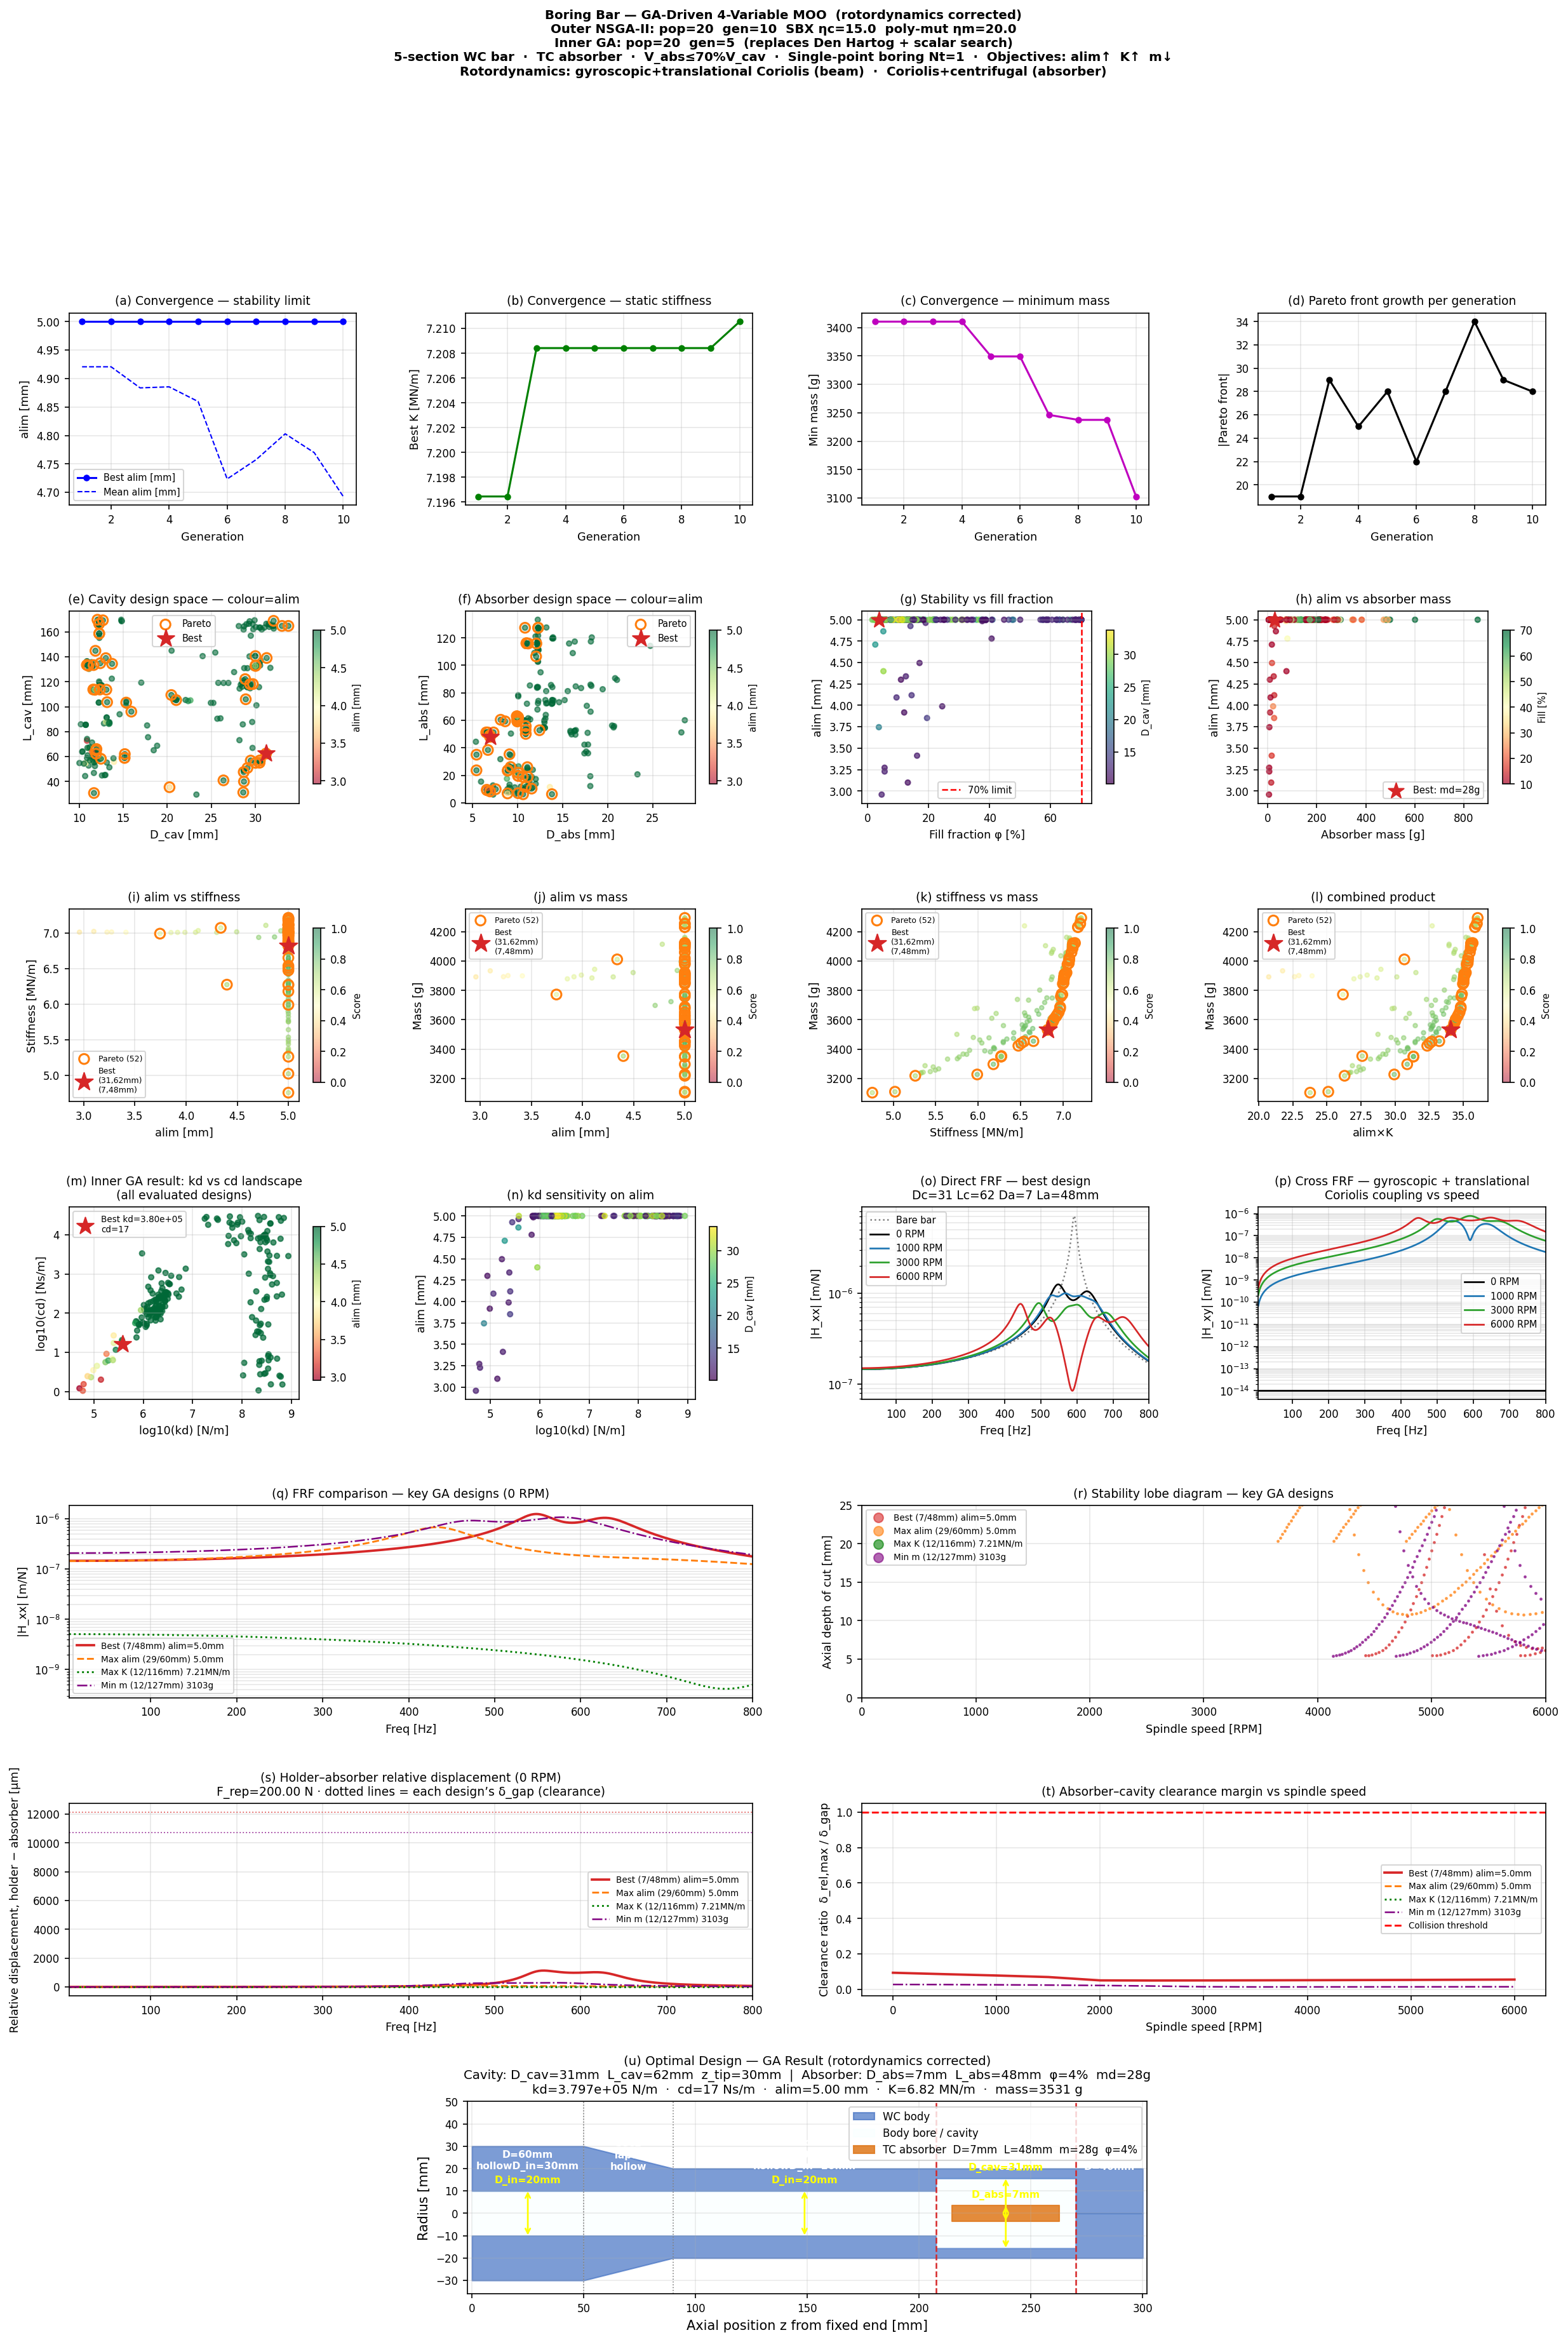

In [ ]:
make_plots(all_results, pareto_front, history)